# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('/content/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

In [ ]:
days=df['tpep_pickup_datetime'].dt.day.unique()
hours=df['tpep_pickup_datetime'].dt.hour.unique()

In [ ]:
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

# sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

# sampled_data = pd.concat([sampled_data, sample])
sampled_data = pd.DataFrame()
for i in days:
  for j in hours:
    hour_data=df[(df['tpep_pickup_datetime'].dt.day==i) & (df['tpep_pickup_datetime'].dt.hour==j)]
    sample=hour_data.sample(frac=0.05,random_state=42)
    sampled_data=pd.concat([sampled_data,sample])

In [ ]:
sampled_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
3703,2,2023-01-01 00:31:50,2023-01-01 00:44:17,2.0,2.85,1.0,N,263,41,1,15.60,1.0,0.5,4.12,0.0,1.0,24.72,2.5,0.0
4166,2,2023-01-01 00:10:50,2023-01-01 00:24:12,4.0,1.32,1.0,N,90,137,1,12.80,1.0,0.5,3.56,0.0,1.0,21.36,2.5,0.0
3847,2,2023-01-01 00:25:37,2023-01-01 00:34:52,1.0,3.17,1.0,N,79,141,1,14.90,1.0,0.5,3.98,0.0,1.0,23.88,2.5,0.0
1882,2,2023-01-01 00:27:26,2023-01-01 00:52:20,2.0,3.80,1.0,N,142,107,2,24.70,1.0,0.5,0.00,0.0,1.0,29.70,2.5,0.0
2995366,2,2023-01-01 00:59:15,2023-01-01 01:23:15,NaN,7.97,NaN,None,140,17,0,36.83,0.0,0.5,8.17,0.0,1.0,49.00,NaN,NaN


---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Assignments/EDA/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        df_temp=pd.read_parquet(file_path)


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe
        days=df_temp['tpep_pickup_datetime'].dt.day.unique()
        hours=df_temp['tpep_pickup_datetime'].dt.hour.unique()
        for i in days:
          for j in hours:
            hour_data=df_temp[(df_temp['tpep_pickup_datetime'].dt.day==i) & (df_temp['tpep_pickup_datetime'].dt.hour==j)]
            sample=hour_data.sample(frac=0.05,random_state=42)
            sampled_data=pd.concat([sampled_data,sample])


        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896420 entries, 3703 to 3036647
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            f

In [ ]:
df_temp=df

In [ ]:
df_temp['month']=df_temp['tpep_pickup_datetime'].dt.month


In [ ]:
df_temp.groupby('month').count()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
month,,,,,,,,,,,,,,,,,,,,
1,152089,152089,152089,148484,152089,148484,148484,152089,152089,152089,152089,152089,152089,152089,152089,152089,152089,148484,148480,4
2,144461,144461,144461,140726,144461,140726,140726,144461,144461,144461,144461,144461,144461,144461,144461,144461,144461,140726,0,140726
3,168700,168700,168700,164304,168700,164304,164304,168700,168700,168700,168700,168700,168700,168700,168700,168700,168700,164304,0,164304
4,162914,162914,162914,158392,162914,158392,158392,162914,162914,162914,162914,162914,162914,162914,162914,162914,162914,158392,0,158392
5,174072,174072,174072,168980,174072,168980,168980,174072,174072,174072,174072,174072,174072,174072,174072,174072,174072,168980,0,168980
6,163785,163785,163785,159006,163785,159006,159006,163785,163785,163785,163785,163785,163785,163785,163785,163785,163785,159006,0,159006
7,143785,143785,143785,139732,143785,139732,139732,143785,143785,143785,143785,143785,143785,143785,143785,143785,143785,139732,0,139732
8,139641,139641,139641,135262,139641,135262,135262,139641,139641,139641,139641,139641,139641,139641,139641,139641,139641,135262,0,135262
9,140876,140876,140876,133939,140876,133939,133939,140876,140876,140876,140876,140876,140876,140876,140876,140876,140876,133939,0,133939


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet('processed_df.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [197]:
# Load the new data file

ndf=pd.read_parquet('/content/processed_df.parquet')

In [198]:
ndf.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,month
3703,2,2023-01-01 00:31:50,2023-01-01 00:44:17,2.0,2.85,1.0,N,263,41,1,...,1.0,0.5,4.12,0.0,1.0,24.72,2.5,0.0,NaN,1
4166,2,2023-01-01 00:10:50,2023-01-01 00:24:12,4.0,1.32,1.0,N,90,137,1,...,1.0,0.5,3.56,0.0,1.0,21.36,2.5,0.0,NaN,1
3847,2,2023-01-01 00:25:37,2023-01-01 00:34:52,1.0,3.17,1.0,N,79,141,1,...,1.0,0.5,3.98,0.0,1.0,23.88,2.5,0.0,NaN,1
1882,2,2023-01-01 00:27:26,2023-01-01 00:52:20,2.0,3.80,1.0,N,142,107,2,...,1.0,0.5,0.00,0.0,1.0,29.70,2.5,0.0,NaN,1
2995366,2,2023-01-01 00:59:15,2023-01-01 01:23:15,NaN,7.97,NaN,None,140,17,0,...,0.0,0.5,8.17,0.0,1.0,49.00,NaN,NaN,NaN,1


In [199]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896420 entries, 3703 to 3036647
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            f

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [200]:
# Fix the index and drop any columns that are not needed
ndf.drop(columns='month',axis=1,inplace=True)


In [201]:
ndf.reset_index(drop=True,inplace=True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [202]:
# Combine the two airport fee columns
ndf['AIRPORT_FEE']=ndf['airport_fee'].fillna(0)+ndf['Airport_fee'].fillna(0)


In [203]:
ndf.drop(columns=['airport_fee','Airport_fee'],axis=1,inplace=True)

In [204]:
ndf.rename(columns={'AIRPORT_FEE':'airport_fee'},inplace=True)

In [205]:
# There is no functional signifacance of column: store_and_fwd_flag, so dropping this
ndf.drop(columns='store_and_fwd_flag',axis=1,inplace=True)

In [206]:
# creating a new column pickup_hour,  which could be helpful to analyse conjestions
ndf['pickup_hour']=ndf['tpep_pickup_datetime'].dt.hour

In [207]:
# Creating one more coulmn trip duration which can be helpful in time analysis
ndf['trip_duration']=(ndf['tpep_dropoff_datetime']-ndf['tpep_pickup_datetime']).dt.total_seconds()

In [208]:
# Creating pick up day
ndf['pickup_day']=ndf['tpep_pickup_datetime'].dt.day

In [209]:
# Creating pickup month
ndf['pickup_month']=ndf['tpep_pickup_datetime'].dt.month

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [210]:
# check where values of fare amount are negative
ndf[ndf['fare_amount']<0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


Did you notice something different in the `RatecodeID` column for above records?

In [211]:
# Analyse RatecodeID for the negative fare amounts

# No negetive fare_amount
ndf.shape

(1896420, 22)

In [212]:
ndf[ndf['fare_amount']<0]
# No negetive values

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [213]:
ndf[ndf['extra']<0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
1433054,2,2023-10-06 22:24:42,2023-10-06 22:25:38,2.0,0.03,1.0,161,161,2,0.0,...,0.0,0.0,-1.0,-5.0,-2.5,0.0,22,56.0,6,10
1549185,2,2023-10-27 14:51:03,2023-10-27 14:51:11,1.0,0.00,1.0,265,265,2,3.0,...,0.0,0.0,1.0,4.0,0.0,0.0,14,8.0,27,10
1595304,2,2023-11-06 22:37:04,2023-11-06 22:37:55,1.0,0.03,1.0,229,229,2,0.0,...,0.0,0.0,-1.0,-5.0,-2.5,0.0,22,51.0,6,11


In [214]:
# only 3 negetive values are there which is very less. so dropping this
ndf=ndf[ndf['extra']>=0]

In [215]:
ndf.shape

(1896417, 22)

In [216]:
ndf[ndf['mta_tax']<0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
10515,2,2023-01-24 20:07:00,2023-01-24 20:21:32,1.0,1.81,1.0,237,162,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,20,872.0,24,1
19076,2,2023-01-25 18:52:24,2023-01-25 19:06:34,1.0,1.75,1.0,140,163,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,18,850.0,25,1
22927,2,2023-01-03 14:24:45,2023-01-03 14:25:14,1.0,0.00,2.0,132,132,2,0.0,...,0.0,0.0,-1.0,-5.25,-2.5,-1.25,14,29.0,3,1
91780,2,2023-01-17 15:03:44,2023-01-17 15:36:28,1.0,4.12,1.0,239,168,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,15,1964.0,17,1
94945,2,2023-01-17 12:37:35,2023-01-17 13:24:00,1.0,17.68,2.0,230,132,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,12,2785.0,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784084,2,2023-12-09 08:34:26,2023-12-09 08:34:35,1.0,0.00,2.0,107,137,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,8,9.0,9,12
1804639,2,2023-12-12 06:57:09,2023-12-12 07:16:37,1.0,3.30,1.0,164,239,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,6,1168.0,12,12
1839196,2,2023-12-17 08:10:57,2023-12-17 08:28:46,1.0,11.27,1.0,132,70,2,0.0,...,0.0,0.0,-1.0,-3.25,0.0,-1.75,8,1069.0,17,12
1851362,2,2023-12-19 15:33:14,2023-12-19 16:05:27,2.0,5.83,1.0,186,87,2,0.0,...,0.0,0.0,-1.0,-4.00,-2.5,0.00,15,1933.0,19,12


In [217]:
# Find which columns have negative values
len(ndf[ndf['mta_tax']<0])/len(ndf)*100


0.003849364353936924

In [218]:
# mta_tax is having 73 records which is very low around .003%. so dropping the rows
ndf=ndf[ndf['mta_tax']>=0]



In [219]:
ndf.shape

(1896344, 22)

In [220]:
ndf[ndf['tip_amount']<0]
# No negetive records for tip_amount

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [221]:
ndf[ndf['tolls_amount']<0]
# No negetive values for tolls_amount

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [222]:
len(ndf[ndf['improvement_surcharge']<0])/len(ndf)*100

0.00026366524217125164

In [223]:
# dropping the negetive records for improvement_surchargeas the percentage is .0002
ndf=ndf[ndf['improvement_surcharge']>=0]

In [224]:
ndf.shape

(1896339, 22)

In [225]:
ndf[ndf['total_amount']<0]
# no negetive record

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [226]:
ndf[ndf['congestion_surcharge']<0]
# No negetive records

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [227]:
ndf[ndf['airport_fee']<0]
# No negetive records

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [229]:
# Find the proportion of missing values in each column

ndf.isnull().sum()/len(ndf)*100

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,3.421066
trip_distance,0.000000
RatecodeID,3.421066
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [230]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
ndf[ndf['passenger_count'].isnull()]
# the passenger_count can not be NAN as there is a valid fare respective to the record. imputing the NAN with the mode passenger count


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
4,2,2023-01-01 00:59:15,2023-01-01 01:23:15,NaN,7.97,NaN,140,17,0,36.83,...,8.17,0.00,1.0,49.00,NaN,0.0,0,1440.0,1,1
6,2,2023-01-01 00:39:50,2023-01-01 00:54:29,NaN,7.53,NaN,213,7,0,30.97,...,4.00,6.55,1.0,43.02,NaN,0.0,0,879.0,1,1
8,2,2023-01-01 00:43:47,2023-01-01 00:56:12,NaN,5.36,NaN,88,229,0,24.51,...,4.28,0.00,1.0,32.79,NaN,0.0,0,745.0,1,1
17,2,2023-01-01 00:33:00,2023-01-01 01:01:00,NaN,6.90,NaN,45,188,0,33.49,...,2.00,0.00,1.0,39.49,NaN,0.0,0,1680.0,1,1
26,2,2023-01-01 00:33:00,2023-01-01 00:57:00,NaN,5.11,NaN,255,229,0,24.04,...,5.61,0.00,1.0,33.65,NaN,0.0,0,1440.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896193,2,2023-12-29 20:33:43,2023-12-29 20:50:06,NaN,2.60,NaN,161,114,0,18.97,...,0.00,0.00,1.0,22.97,NaN,0.0,20,983.0,29,12
1896246,2,2023-12-29 21:18:26,2023-12-29 21:37:17,NaN,5.70,NaN,161,88,0,33.69,...,7.54,0.00,1.0,45.23,NaN,0.0,21,1131.0,29,12
1896293,1,2023-12-29 21:58:55,2023-12-29 22:09:37,NaN,1.70,NaN,239,141,0,12.10,...,1.71,0.00,1.0,18.81,NaN,0.0,21,642.0,29,12
1896381,2,2023-12-29 21:35:20,2023-12-29 21:50:44,NaN,2.00,NaN,137,211,0,14.87,...,2.83,0.00,1.0,21.70,NaN,0.0,21,924.0,29,12


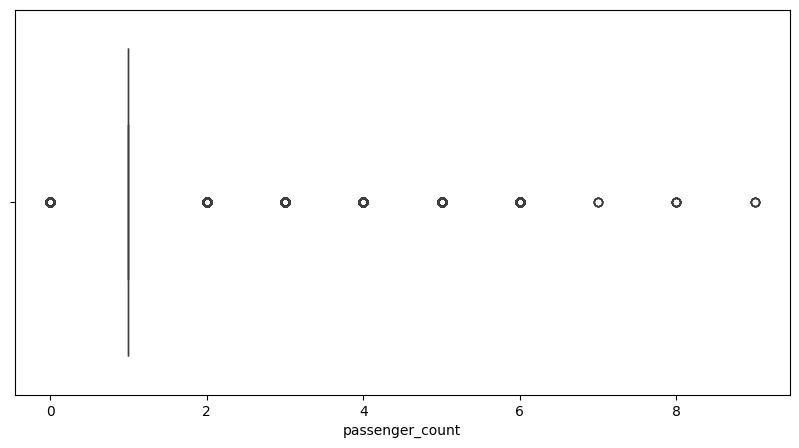

In [231]:
plt.figure(figsize=(10,5))
sns.boxplot(x=ndf['passenger_count'])
plt.show()

In [232]:
ndf['passenger_count'].value_counts()

,count
passenger_count,
1.0,1377280
2.0,277229
3.0,68967
4.0,38542
0.0,29683
5.0,23875
6.0,15866
8.0,11
9.0,6


In [233]:
ndf['passenger_count'].mode()

,passenger_count
0,1.0


In [234]:
# filling nan with the mode of the passenger_count which is 1
ndf['passenger_count'].fillna(1,inplace=True)

In [235]:
ndf[ndf['passenger_count'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [236]:
ndf['passenger_count'].value_counts()

,count
passenger_count,
1.0,1442155
2.0,277229
3.0,68967
4.0,38542
0.0,29683
5.0,23875
6.0,15866
8.0,11
9.0,6


Did you find zeroes in passenger_count? Handle these.

In [237]:
ndf[ndf['passenger_count']==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
13,1,2023-01-01 00:08:49,2023-01-01 00:26:15,0.0,1.5,1.0,170,43,2,16.3,...,0.00,0.0,1.0,21.30,2.5,0.0,0,1046.0,1,1
38,1,2023-01-01 00:25:02,2023-01-01 00:37:23,0.0,6.4,1.0,75,79,2,25.4,...,0.00,0.0,1.0,30.40,2.5,0.0,0,741.0,1,1
72,1,2023-01-01 00:42:48,2023-01-01 00:52:02,0.0,1.0,1.0,162,161,1,10.0,...,1.50,0.0,1.0,16.50,2.5,0.0,0,554.0,1,1
75,1,2023-01-01 00:23:01,2023-01-01 00:32:42,0.0,2.4,1.0,43,166,1,12.8,...,2.20,0.0,1.0,20.00,2.5,0.0,0,581.0,1,1
123,1,2023-01-01 00:56:10,2023-01-01 01:08:18,0.0,2.0,1.0,148,264,1,13.5,...,3.70,0.0,1.0,22.20,2.5,0.0,0,728.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896165,1,2023-12-29 20:24:42,2023-12-29 20:41:31,0.0,0.6,1.0,170,161,2,14.2,...,0.00,0.0,1.0,19.20,2.5,0.0,20,1009.0,29,12
1896168,1,2023-12-29 20:35:21,2023-12-29 20:41:40,0.0,1.3,1.0,263,75,2,8.6,...,0.00,0.0,1.0,13.60,2.5,0.0,20,379.0,29,12
1896177,1,2023-12-29 20:35:06,2023-12-29 20:45:20,0.0,2.0,1.0,142,236,1,12.8,...,3.55,0.0,1.0,21.35,2.5,0.0,20,614.0,29,12
1896294,1,2023-12-29 21:47:25,2023-12-29 21:52:09,0.0,0.6,1.0,113,79,2,6.5,...,0.00,0.0,1.0,11.50,2.5,0.0,21,284.0,29,12


In [238]:
# same goes for value 0 which is not a valid entry also cannot be dropped as the records are more. replacing the value with mode value
ndf['passenger_count'].replace(0,1,inplace=True)

In [239]:
ndf[ndf['passenger_count']==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


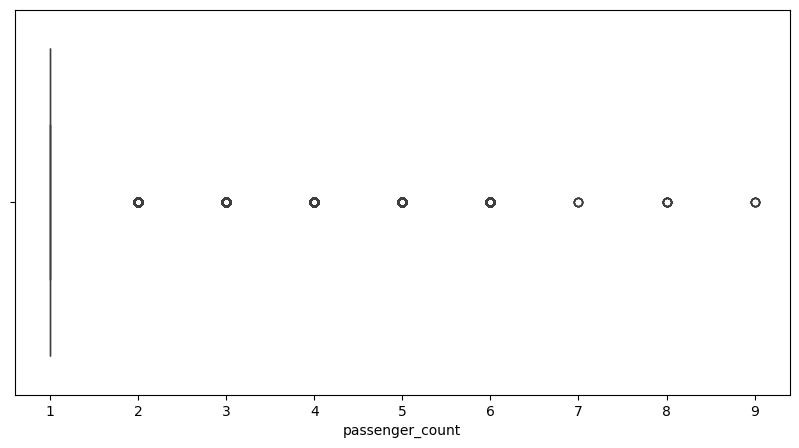

In [240]:
plt.figure(figsize=(10,5))
sns.boxplot(x=ndf['passenger_count'])
plt.show()

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [241]:
# Fix missing values in 'RatecodeID'
ndf.isnull().sum()/len(ndf)*100

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.000000
trip_distance,0.000000
RatecodeID,3.421066
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


In [242]:
ndf[ndf['RatecodeID'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
4,2,2023-01-01 00:59:15,2023-01-01 01:23:15,1.0,7.97,NaN,140,17,0,36.83,...,8.17,0.00,1.0,49.00,NaN,0.0,0,1440.0,1,1
6,2,2023-01-01 00:39:50,2023-01-01 00:54:29,1.0,7.53,NaN,213,7,0,30.97,...,4.00,6.55,1.0,43.02,NaN,0.0,0,879.0,1,1
8,2,2023-01-01 00:43:47,2023-01-01 00:56:12,1.0,5.36,NaN,88,229,0,24.51,...,4.28,0.00,1.0,32.79,NaN,0.0,0,745.0,1,1
17,2,2023-01-01 00:33:00,2023-01-01 01:01:00,1.0,6.90,NaN,45,188,0,33.49,...,2.00,0.00,1.0,39.49,NaN,0.0,0,1680.0,1,1
26,2,2023-01-01 00:33:00,2023-01-01 00:57:00,1.0,5.11,NaN,255,229,0,24.04,...,5.61,0.00,1.0,33.65,NaN,0.0,0,1440.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896193,2,2023-12-29 20:33:43,2023-12-29 20:50:06,1.0,2.60,NaN,161,114,0,18.97,...,0.00,0.00,1.0,22.97,NaN,0.0,20,983.0,29,12
1896246,2,2023-12-29 21:18:26,2023-12-29 21:37:17,1.0,5.70,NaN,161,88,0,33.69,...,7.54,0.00,1.0,45.23,NaN,0.0,21,1131.0,29,12
1896293,1,2023-12-29 21:58:55,2023-12-29 22:09:37,1.0,1.70,NaN,239,141,0,12.10,...,1.71,0.00,1.0,18.81,NaN,0.0,21,642.0,29,12
1896381,2,2023-12-29 21:35:20,2023-12-29 21:50:44,1.0,2.00,NaN,137,211,0,14.87,...,2.83,0.00,1.0,21.70,NaN,0.0,21,924.0,29,12


In [243]:
ndf['RatecodeID'].value_counts()

,count
RatecodeID,
1.0,1729294
2.0,71561
99.0,10477
5.0,10290
3.0,6122
4.0,3717
6.0,3


In [244]:
# filling null values with 99 as it signifies null/unknown value
ndf['RatecodeID'].fillna(99,inplace=True)

In [245]:
ndf[ndf['RatecodeID'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


In [246]:
ndf.isnull().sum()/len(ndf)*100

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.000000
trip_distance,0.000000
RatecodeID,0.000000
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [247]:
# handle null values in congestion_surcharge

ndf[ndf['congestion_surcharge'].isnull()]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
4,2,2023-01-01 00:59:15,2023-01-01 01:23:15,1.0,7.97,99.0,140,17,0,36.83,...,8.17,0.00,1.0,49.00,NaN,0.0,0,1440.0,1,1
6,2,2023-01-01 00:39:50,2023-01-01 00:54:29,1.0,7.53,99.0,213,7,0,30.97,...,4.00,6.55,1.0,43.02,NaN,0.0,0,879.0,1,1
8,2,2023-01-01 00:43:47,2023-01-01 00:56:12,1.0,5.36,99.0,88,229,0,24.51,...,4.28,0.00,1.0,32.79,NaN,0.0,0,745.0,1,1
17,2,2023-01-01 00:33:00,2023-01-01 01:01:00,1.0,6.90,99.0,45,188,0,33.49,...,2.00,0.00,1.0,39.49,NaN,0.0,0,1680.0,1,1
26,2,2023-01-01 00:33:00,2023-01-01 00:57:00,1.0,5.11,99.0,255,229,0,24.04,...,5.61,0.00,1.0,33.65,NaN,0.0,0,1440.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896193,2,2023-12-29 20:33:43,2023-12-29 20:50:06,1.0,2.60,99.0,161,114,0,18.97,...,0.00,0.00,1.0,22.97,NaN,0.0,20,983.0,29,12
1896246,2,2023-12-29 21:18:26,2023-12-29 21:37:17,1.0,5.70,99.0,161,88,0,33.69,...,7.54,0.00,1.0,45.23,NaN,0.0,21,1131.0,29,12
1896293,1,2023-12-29 21:58:55,2023-12-29 22:09:37,1.0,1.70,99.0,239,141,0,12.10,...,1.71,0.00,1.0,18.81,NaN,0.0,21,642.0,29,12
1896381,2,2023-12-29 21:35:20,2023-12-29 21:50:44,1.0,2.00,99.0,137,211,0,14.87,...,2.83,0.00,1.0,21.70,NaN,0.0,21,924.0,29,12


In [248]:
ndf['congestion_surcharge'].value_counts()

,count
congestion_surcharge,
2.5,1690621
0.0,140842
0.5,1


In [249]:
# congestion_surcharge is a specialised ammount that collected for NYS congestion surcharge, if the value is missing we can impute with 0, meaning no surcharge
ndf['congestion_surcharge'].fillna(0,inplace=True)

In [250]:
ndf.isnull().sum()/len(ndf)*100

,0
VendorID,0.0
tpep_pickup_datetime,0.0
tpep_dropoff_datetime,0.0
passenger_count,0.0
trip_distance,0.0
RatecodeID,0.0
PULocationID,0.0
DOLocationID,0.0
payment_type,0.0
fare_amount,0.0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [251]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
ndf.describe()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
count,1.896339e+06,1896339,1896339,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,...,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06,1.896339e+06
mean,1.733088e+00,2023-07-02 19:31:53.163020,2023-07-02 19:49:18.871293,1.372177e+00,3.843700e+00,4.965866e+00,1.652696e+02,1.640441e+02,1.163778e+00,1.991727e+01,...,3.547129e+00,5.964458e-01,9.990543e-01,2.898046e+01,2.228796e+00,1.380311e-01,1.426506e+01,1.045708e+03,1.551783e+01,6.540130e+00
min,1.000000e+00,2001-01-01 00:06:49,2001-01-01 15:42:11,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.258000e+03,1.000000e+00,1.000000e+00
25%,1.000000e+00,2023-04-02 16:08:42.500000,2023-04-02 16:27:08,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00,1.100000e+01,4.600000e+02,8.000000e+00,4.000000e+00
50%,2.000000e+00,2023-06-27 15:42:18,2023-06-27 15:59:01,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,...,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00,1.500000e+01,7.600000e+02,1.500000e+01,6.000000e+00
75%,2.000000e+00,2023-10-06 19:35:55.500000,2023-10-06 19:51:59.500000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,...,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00,1.900000e+01,1.241000e+03,2.300000e+01,1.000000e+01
max,6.000000e+00,2024-01-01 00:01:34,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,...,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00,2.300000e+01,3.759830e+05,3.100000e+01,1.200000e+01
std,4.475841e-01,NaN,NaN,8.644413e-01,1.271909e+02,1.913236e+01,6.400076e+01,6.980101e+01,5.080874e-01,1.055388e+02,...,4.056790e+00,2.187060e+00,2.833469e-02,1.064181e+02,7.774689e-01,4.575895e-01,5.807420e+00,2.461319e+03,8.695638e+00,3.466799e+00


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [252]:
# remove passenger_count > 6
ndf=ndf[ndf['passenger_count']<=6]


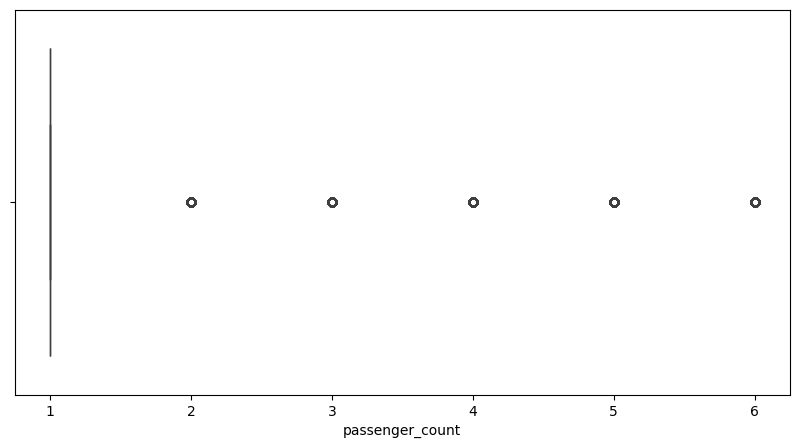

In [253]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,x=ndf['passenger_count'])
plt.show()

In [255]:
# Outlier handling for trip Distance
ndf['trip_distance'].describe()

,trip_distance
count,1.896317e+06
mean,3.843684e+00
std,1.271917e+02
min,0.000000e+00
25%,1.050000e+00
50%,1.790000e+00
75%,3.400000e+00
max,1.263605e+05


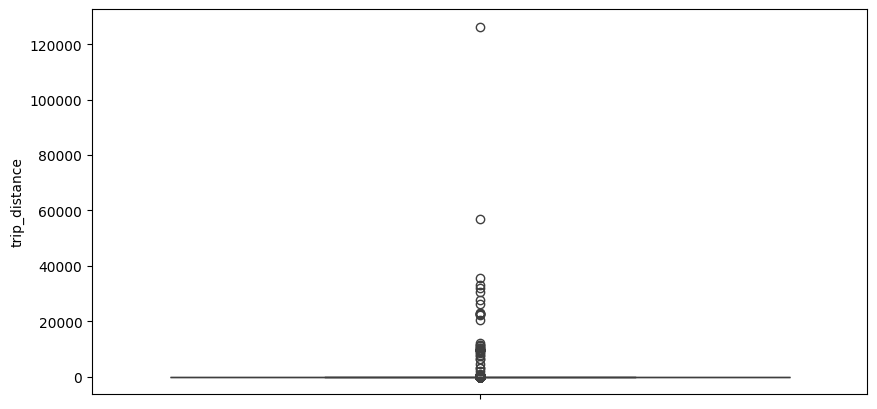

In [256]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['trip_distance'])
plt.show()

In [257]:
# To make our analysis realistinc in the context of taxi data, removing the extreme condition where trip_distance > 250
ndf=ndf[ndf['trip_distance']<=250]

In [258]:
# trip distance can not be 0 so its also potentially an outlier
ndf=ndf[ndf['trip_distance']!=0]

In [259]:
ndf.fare_amount.describe()

,fare_amount
count,1.858574e+06
mean,1.980165e+01
std,1.065083e+02
min,0.000000e+00
25%,9.300000e+00
50%,1.350000e+01
75%,2.190000e+01
max,1.431635e+05


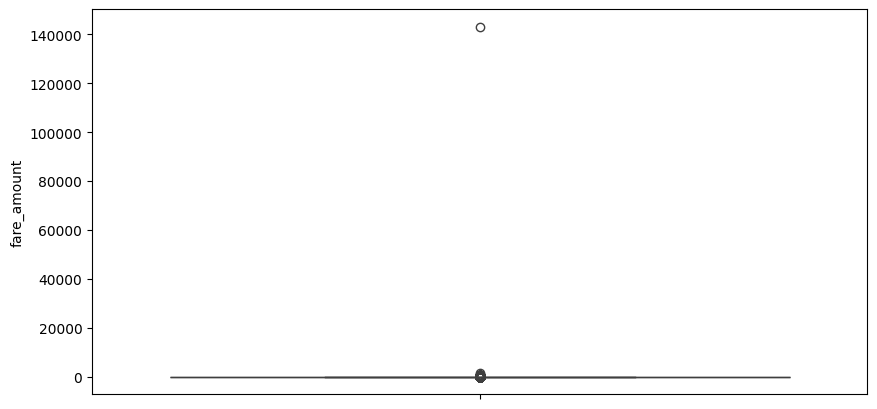

In [260]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['fare_amount'])
plt.show()

In [261]:
# fare_amount can not be 0
ndf=ndf[ndf['fare_amount']!=0]

In [265]:
ndf.shape

(1858304, 22)

In [263]:
# from the box plot there is a single extreme value which is unrealistic need to be removed
# ndf=ndf[ndf.fare_amount != ndf.fare_amount.max()]

In [264]:
# not visible outlier and extra as a column can have 0 or more value to it
ndf.extra.describe()

,extra
count,1.858304e+06
mean,1.609562e+00
std,1.832665e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,2.500000e+00
max,1.425000e+01


In [266]:
ndf.mta_tax.describe()

,mta_tax
count,1.858304e+06
mean,4.968043e-01
std,4.017845e-02
min,0.000000e+00
25%,5.000000e-01
50%,5.000000e-01
75%,5.000000e-01
max,4.000000e+00


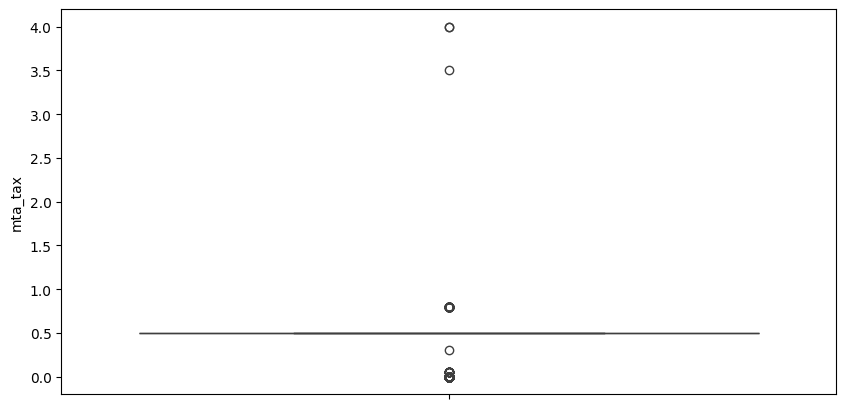

In [267]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['mta_tax'])
plt.show()

In [268]:
# Most of the data points is 0.5 but there could be a legitment mta_tax not true outliers

In [269]:
# No outliers observed
ndf.tip_amount.describe()

,tip_amount
count,1.858304e+06
mean,3.578988e+00
std,3.992896e+00
min,0.000000e+00
25%,1.000000e+00
50%,2.880000e+00
75%,4.480000e+00
max,2.230800e+02


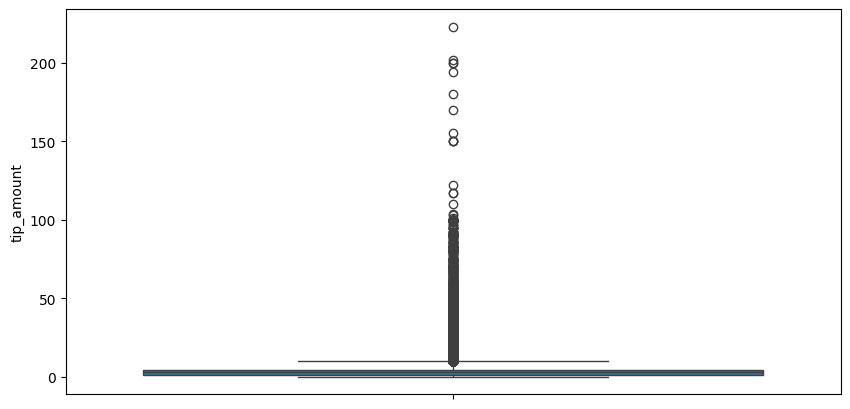

In [270]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['tip_amount'])
plt.show()

In [271]:
# There could be possibility of any tolls amount so no outliers
ndf.tolls_amount.describe()

,tolls_amount
count,1.858304e+06
mean,5.979163e-01
std,2.178919e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,9.500000e+01


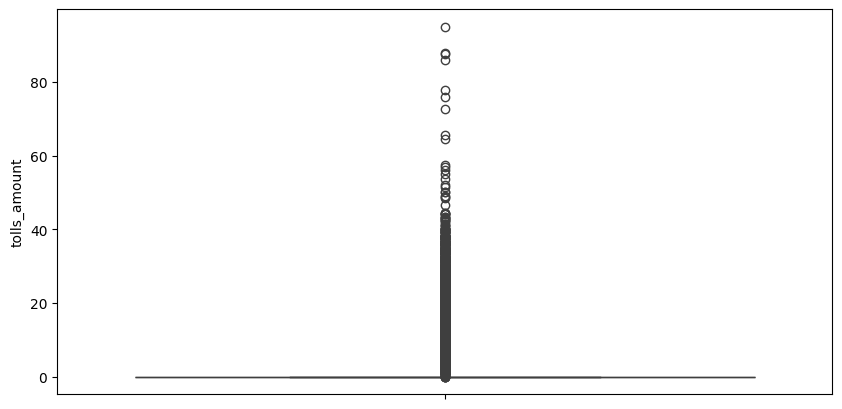

In [272]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['tolls_amount'])
plt.show()

In [273]:
# no potential surcharge outliers detected
ndf.improvement_surcharge.describe()

,improvement_surcharge
count,1.858304e+06
mean,9.994928e-01
std,1.912976e-02
min,0.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


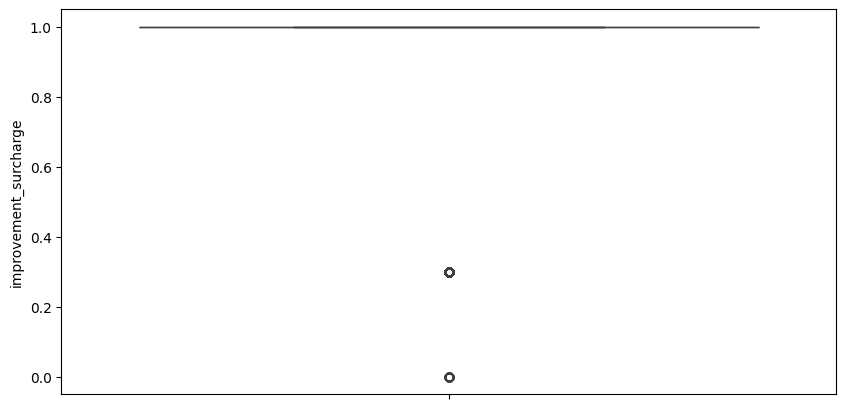

In [274]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['improvement_surcharge'])
plt.show()

In [275]:
# no potential outliers found
ndf.total_amount.describe()

,total_amount
count,1.858304e+06
mean,2.885398e+01
std,2.250853e+01
min,1.010000e+00
25%,1.600000e+01
50%,2.100000e+01
75%,3.080000e+01
max,1.435190e+03


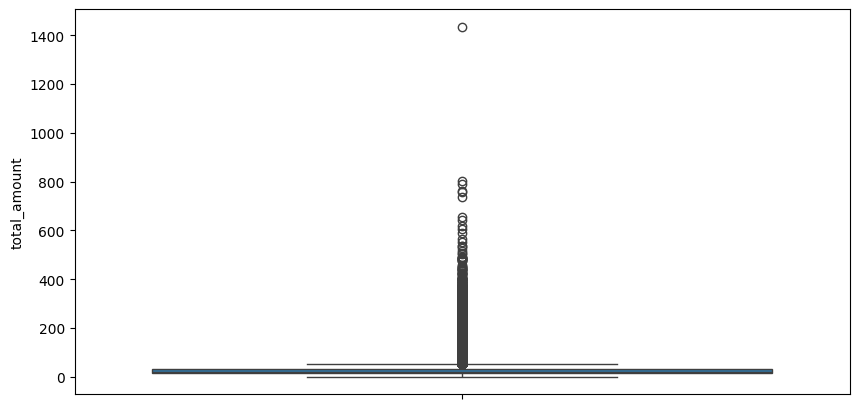

In [276]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['total_amount'])
plt.show()

In [277]:
# No potential outliers found
ndf.congestion_surcharge.describe()

,congestion_surcharge
count,1.858304e+06
mean,2.260528e+00
std,7.357535e-01
min,0.000000e+00
25%,2.500000e+00
50%,2.500000e+00
75%,2.500000e+00
max,2.500000e+00


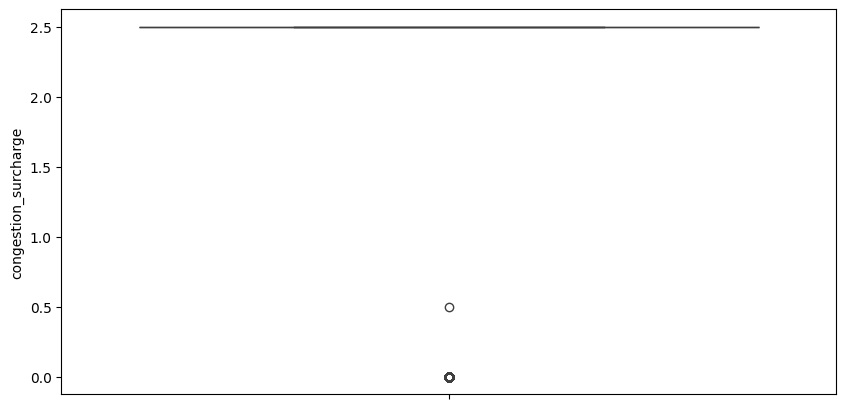

In [278]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['congestion_surcharge'])
plt.show()

In [279]:
# No outliers
ndf.airport_fee.describe()

,airport_fee
count,1.858304e+06
mean,1.389766e-01
std,4.590036e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.750000e+00


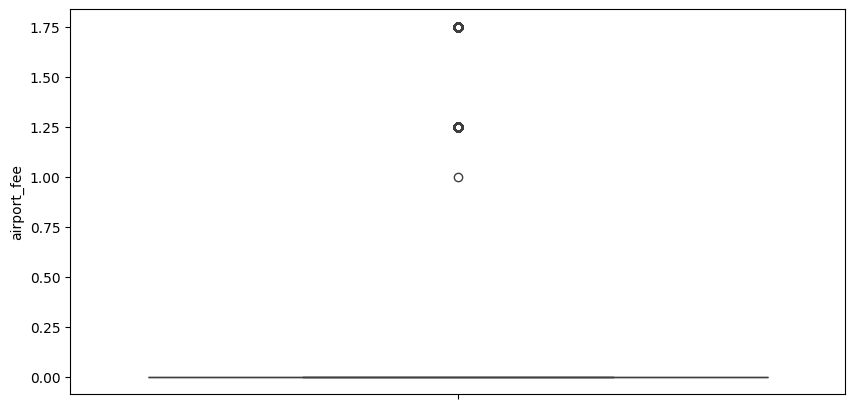

In [280]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ndf,y=ndf['airport_fee'])
plt.show()

In [281]:
ndf.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
count,1.858304e+06,1858304,1858304,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,...,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06,1.858304e+06
mean,1.740168e+00,2023-07-02 03:55:32.481361,2023-07-02 04:13:03.719915,1.375611e+00,3.512897e+00,4.194782e+00,1.653470e+02,1.640675e+02,1.166777e+00,1.972749e+01,...,3.578988e+00,5.979163e-01,9.994928e-01,2.885398e+01,2.260528e+00,1.389766e-01,1.428052e+01,1.051239e+03,1.551198e+01,6.519000e+00
min,1.000000e+00,2001-01-01 00:06:49,2001-01-01 15:42:11,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.258000e+03,1.000000e+00,1.000000e+00
25%,1.000000e+00,2023-04-02 01:24:34.250000,2023-04-02 01:38:12.750000,1.000000e+00,1.100000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,1.600000e+01,2.500000e+00,0.000000e+00,1.100000e+01,4.660000e+02,8.000000e+00,4.000000e+00
50%,2.000000e+00,2023-06-26 12:22:10.500000,2023-06-26 12:41:01,1.000000e+00,1.810000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,...,2.880000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00,1.500000e+01,7.640000e+02,1.500000e+01,6.000000e+00
75%,2.000000e+00,2023-10-06 02:18:23.250000,2023-10-06 02:30:56.750000,1.000000e+00,3.480000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,...,4.480000e+00,0.000000e+00,1.000000e+00,3.080000e+01,2.500000e+00,0.000000e+00,1.900000e+01,1.244000e+03,2.300000e+01,1.000000e+01
max,6.000000e+00,2024-01-01 00:01:34,2024-01-01 20:50:55,6.000000e+00,2.048600e+02,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.375000e+03,...,2.230800e+02,9.500000e+01,1.000000e+00,1.435190e+03,2.500000e+00,1.750000e+00,2.300000e+01,3.313460e+05,3.100000e+01,1.200000e+01
std,4.439327e-01,NaN,NaN,8.677554e-01,4.549705e+00,1.723668e+01,6.386616e+01,6.976440e+01,4.895519e-01,1.787087e+01,...,3.992896e+00,2.178919e+00,1.912976e-02,2.250853e+01,7.357535e-01,4.590036e-01,5.792875e+00,2.443015e+03,8.695864e+00,3.465303e+00


In [282]:
display(ndf.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month
0,2,2023-01-01 00:31:50,2023-01-01 00:44:17,2.0,2.85,1.0,263,41,1,15.60,...,4.12,0.0,1.0,24.72,2.5,0.0,0,747.0,1,1
1,2,2023-01-01 00:10:50,2023-01-01 00:24:12,4.0,1.32,1.0,90,137,1,12.80,...,3.56,0.0,1.0,21.36,2.5,0.0,0,802.0,1,1
2,2,2023-01-01 00:25:37,2023-01-01 00:34:52,1.0,3.17,1.0,79,141,1,14.90,...,3.98,0.0,1.0,23.88,2.5,0.0,0,555.0,1,1
3,2,2023-01-01 00:27:26,2023-01-01 00:52:20,2.0,3.80,1.0,142,107,2,24.70,...,0.00,0.0,1.0,29.70,2.5,0.0,0,1494.0,1,1
4,2,2023-01-01 00:59:15,2023-01-01 01:23:15,1.0,7.97,99.0,140,17,0,36.83,...,8.17,0.0,1.0,49.00,0.0,0.0,0,1440.0,1,1


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [284]:
ndf.shape

(1858304, 22)

In [285]:
ndf.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'trip_duration',
 'pickup_day',
 'pickup_month']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Datetime
* `tpep_dropoff_datetime`: Datetime
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical

The following monetary parameters belong in the same category, is it categorical or numerical?
Numerical


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

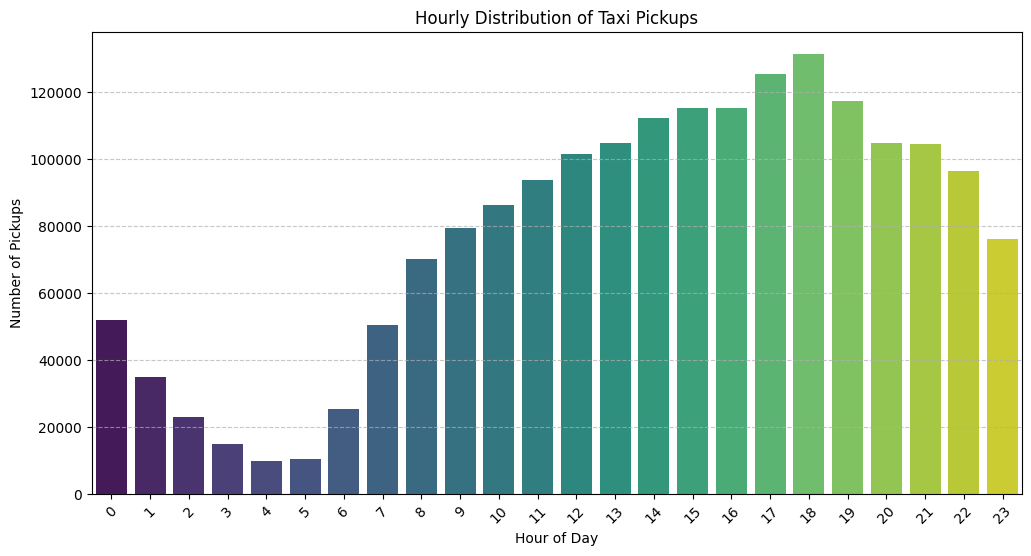

In [286]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = ndf['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')
plt.title('Hourly Distribution of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

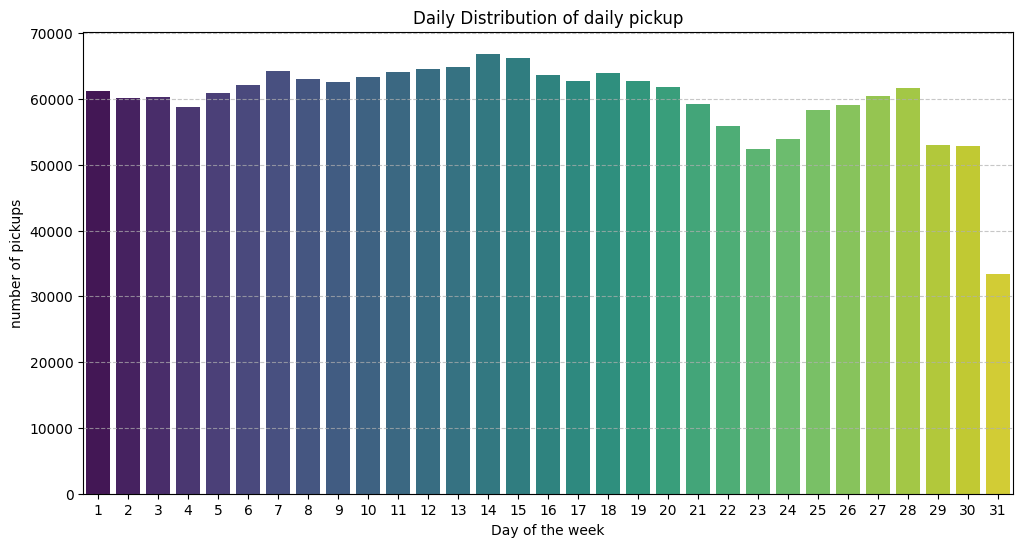

In [287]:
# Find and show the daily trends in taxi pickups (days of the week)
day_pickups = ndf['tpep_pickup_datetime'].dt.day.value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.barplot(x=day_pickups.index,y=day_pickups.values,palette='viridis')
plt.title('Daily Distribution of daily pickup')
plt.xlabel('Day of the week')
plt.ylabel('number of pickups')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

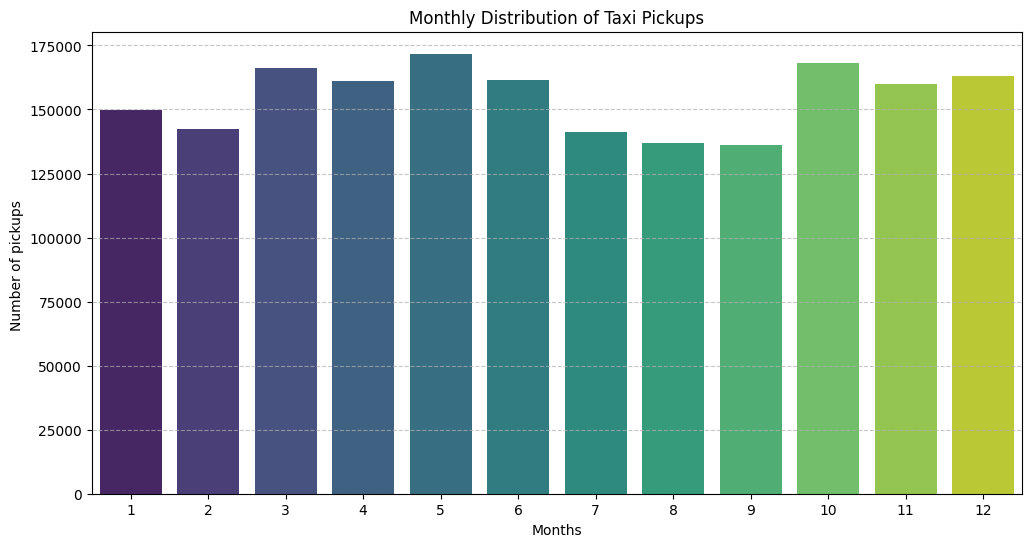

In [288]:

# Show the monthly trends in pickups

monthly_pickups=ndf['tpep_pickup_datetime'].dt.month.value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_pickups.index,y=monthly_pickups.values,palette='viridis')
plt.title('Monthly Distribution of Taxi Pickups')
plt.xlabel('Months')
plt.ylabel('Number of pickups ')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [289]:
# Analyse the above parameters

variable_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
ndf[(ndf["trip_distance"]<0) | (ndf['trip_distance']==0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,pickup_month


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [290]:
# Create a df with non zero entries for the selected parameters.

# apart from the tip_amount all other columns is having no 0 values.
# And coming to tip_amount, this can be any value starts with 0 to anything.
# so no changes required here


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [291]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1858304 entries, 0 to 1896419
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  airport_fee            float64       
 18  pickup_hour            int3

In [292]:
# Group data by month and analyse monthly revenue

ndf.groupby(ndf['tpep_pickup_datetime'].dt.month)['total_amount'].sum()

,total_amount
tpep_pickup_datetime,
1,4090998.74
2,3878521.18
3,4678775.79
4,4600584.87
5,5033878.57
6,4730907.38
7,4097818.39
8,3989842.14
9,4091621.64


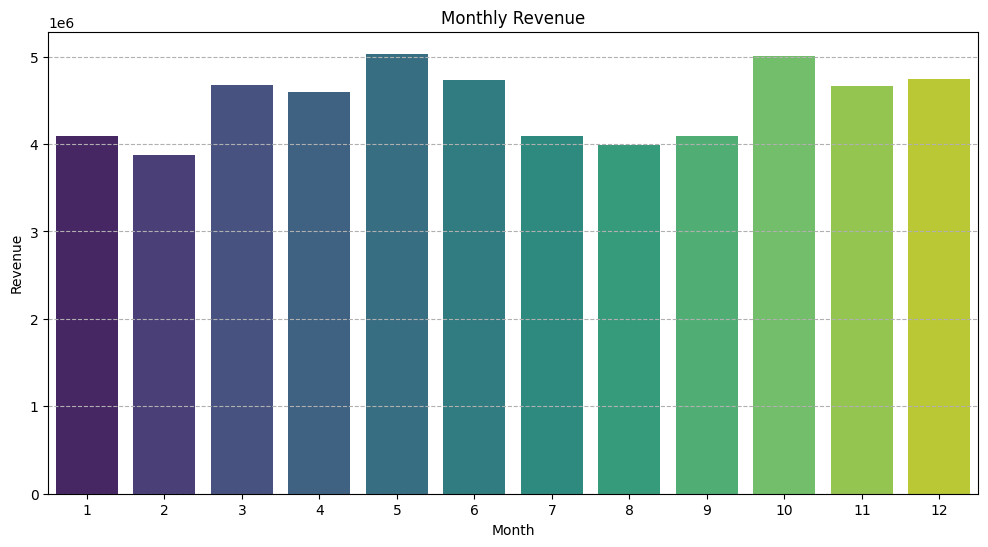

In [293]:
month_group=ndf.groupby(ndf['tpep_pickup_datetime'].dt.month)['total_amount'].sum()
plt.figure(figsize=(12,6))
sns.barplot(x=month_group.index,y=month_group.values,palette='viridis')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(axis='y',linestyle='--')
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [294]:
# Calculate proportion of each quarter
ndf.groupby(ndf['tpep_pickup_datetime'].dt.quarter)['total_amount'].sum()/ndf['total_amount'].sum()


,total_amount
tpep_pickup_datetime,
1,0.235890
2,0.267913
3,0.227143
4,0.269054


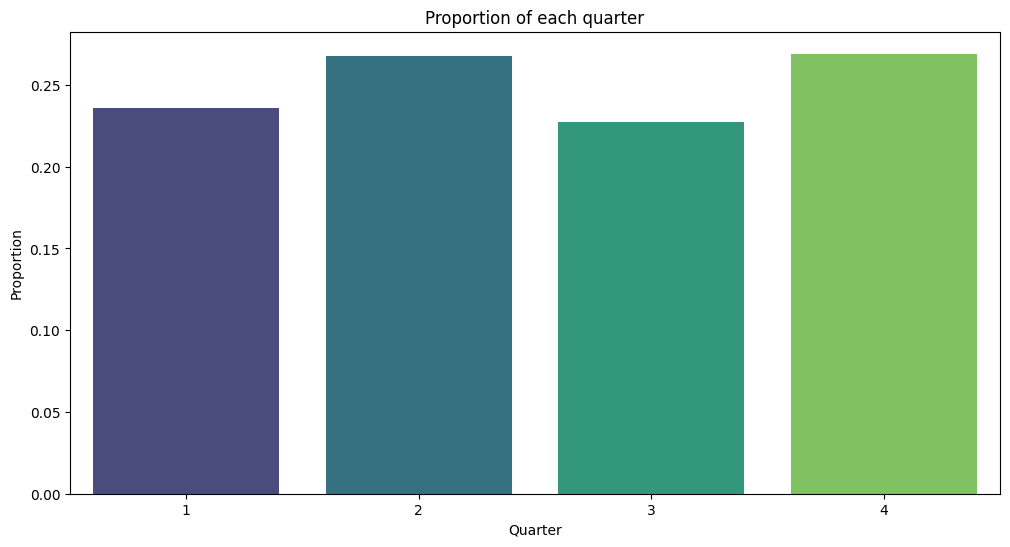

In [295]:
quarter_proportion=ndf.groupby(ndf['tpep_pickup_datetime'].dt.quarter)['total_amount'].sum()/ndf['total_amount'].sum()

plt.figure(figsize=(12,6))
sns.barplot(x=quarter_proportion.index,y=quarter_proportion.values,palette='viridis')
plt.title('Proportion of each quarter')
plt.xlabel('Quarter')
plt.ylabel('Proportion')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [296]:
# Show how trip fare is affected by distance

np.corrcoef(ndf['trip_distance'],ndf['fare_amount'])[0,1]

np.float64(0.9427714077281183)

In [297]:
import scipy
scipy.stats.pearsonr(ndf['trip_distance'],ndf['fare_amount']).statistic

np.float64(0.9427714077281091)

There is a strong positive correlation between `trip_distance` and `fare_amount` which is: `0.9427714077281091`. ~ 94%

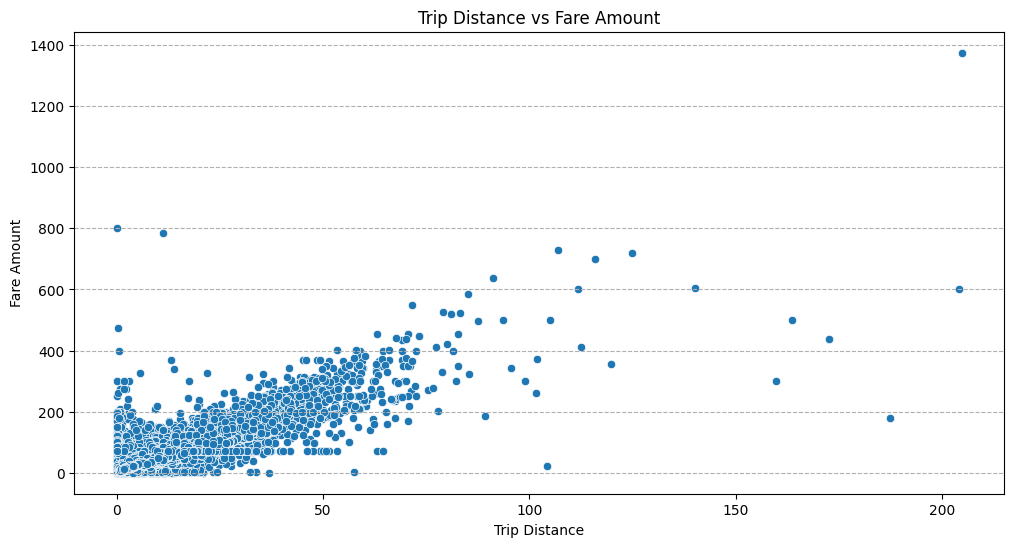

In [298]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=ndf['trip_distance'],y=ndf['fare_amount'],data=ndf)
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.grid(axis='y',linestyle='--')
plt.show()

From above graph it is evident that the with increasing distance there is high chance of getting high fare amount


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [299]:
# Show relationship between fare and trip duration

fare_duration_corr=np.corrcoef(ndf['fare_amount'],ndf['trip_duration'])[0,1]
display(fare_duration_corr)

np.float64(0.27942842301152176)

Observation: from the correlation value: 0.27942842301152176 (~28%) we can not conclude any solid correlation between `fare_amount` and `trip_duration`. Lets plot the relationship

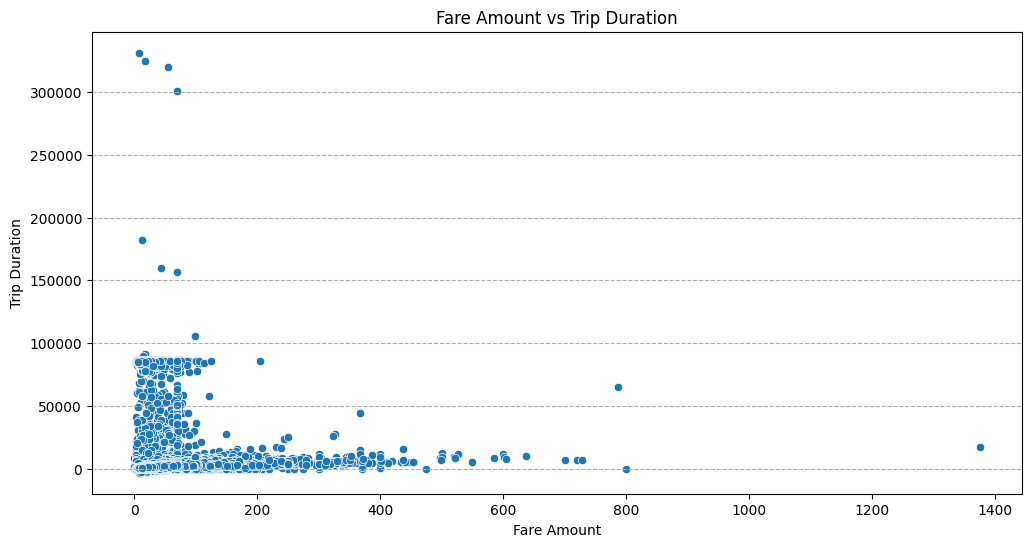

In [300]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=ndf['fare_amount'],y=ndf['trip_duration'],data=ndf)
plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Fare Amount')
plt.ylabel('Trip Duration')
plt.grid(axis='y',linestyle='--')
plt.show()

In [301]:
# Show relationship between fare and number of passengers

fare_passenger_count_corr=np.corrcoef(ndf['fare_amount'],ndf['passenger_count'])[0,1]
display(fare_passenger_count_corr)

np.float64(0.03939005579059102)

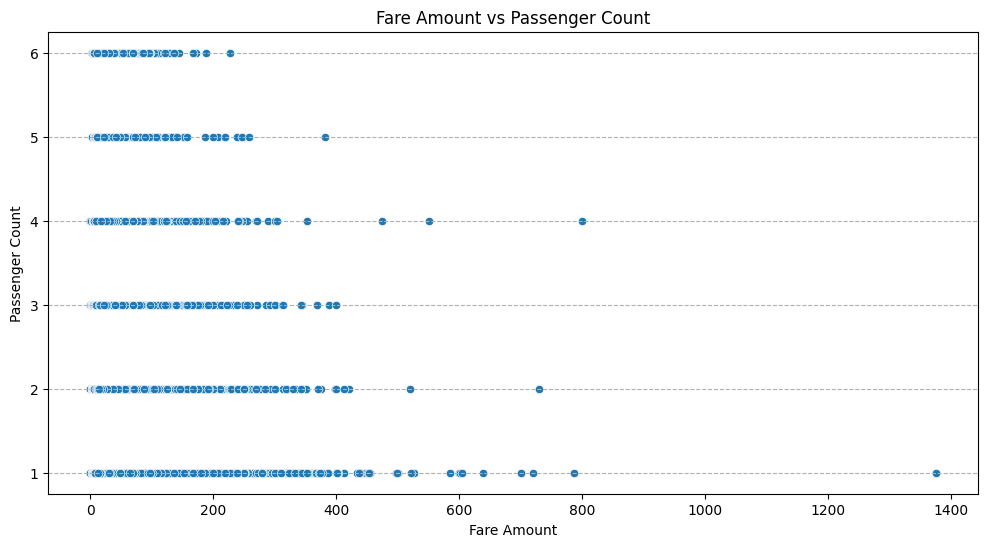

In [302]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=ndf['fare_amount'],y=ndf['passenger_count'],data=ndf)
plt.title('Fare Amount vs Passenger Count')
plt.xlabel('Fare Amount')
plt.ylabel('Passenger Count')
plt.grid(axis='y',linestyle='--')
plt.show()

Observation:
There is no strong correlation between fare amount and the passenger count which is ~4%

In [303]:
# Show relationship between tip and trip distance

tip_trip_distance_corr=np.corrcoef(ndf['tip_amount'],ndf['trip_distance'])[0,1]
display(tip_trip_distance_corr)

np.float64(0.586273025740557)

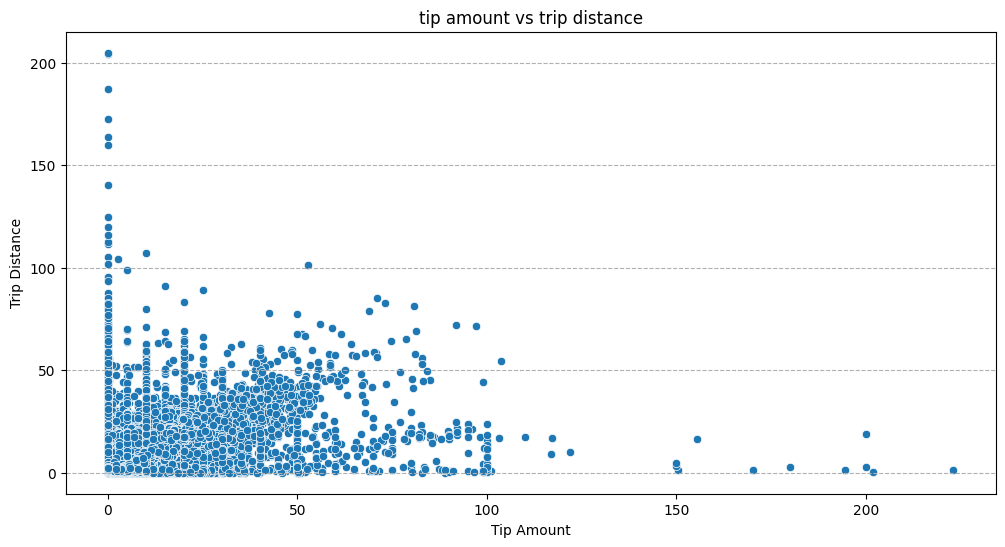

In [304]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=ndf['tip_amount'],y=ndf['trip_distance'],data=ndf)
plt.title('tip amount vs trip distance')
plt.xlabel('Tip Amount')
plt.ylabel('Trip Distance')
plt.grid(axis='y',linestyle='--')
plt.show()

Observation:

There is a positive correlation between tip amount and trip distance, correlation: 0.586273025740557 (~58%) ythat is when trip distance increases the tip amount tends to increase

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [305]:
# Analyse the distribution of different payment types (payment_type).

ndf.groupby('payment_type')['payment_type'].count()

,payment_type
payment_type,
0,50134
1,1479335
2,309821
3,6806
4,12208


In [306]:
# proportions of each payment type
ndf.groupby('payment_type')['payment_type'].count()/ndf['payment_type'].count()

,payment_type
payment_type,
0,0.026978
1,0.796067
2,0.166722
3,0.003662
4,0.006569


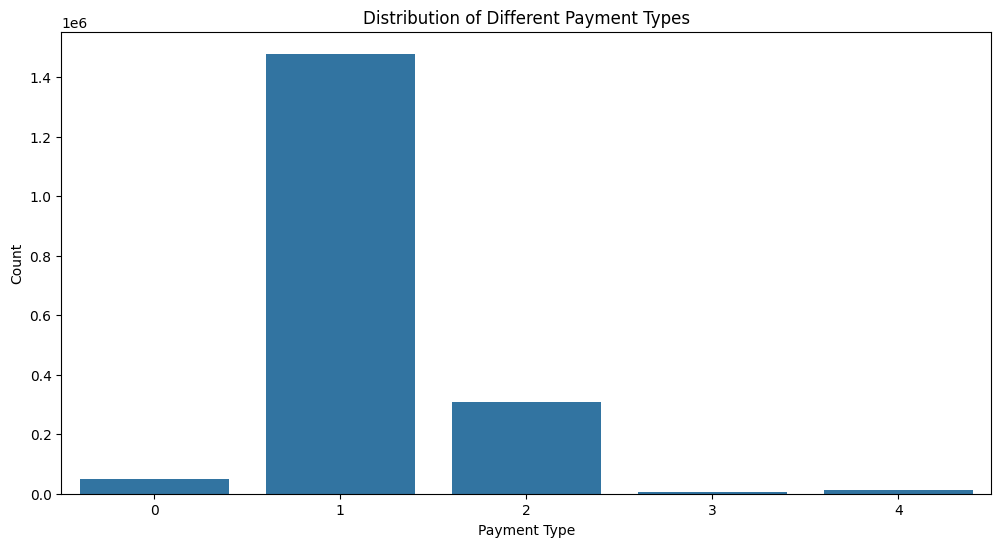

In [307]:
plt.figure(figsize=(12,6))
sns.countplot(data=ndf,x='payment_type')
plt.title('Distribution of Different Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.show()

- 1= Credit card - ~79%
- 2= Cash - ~16%
- 3= No charge - .3%
- 4= Dispute - .6%

Most of the trips were done through credit card which also evident through the plot of different payment type



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [308]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [309]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Assignments/EDA/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [310]:
zones.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

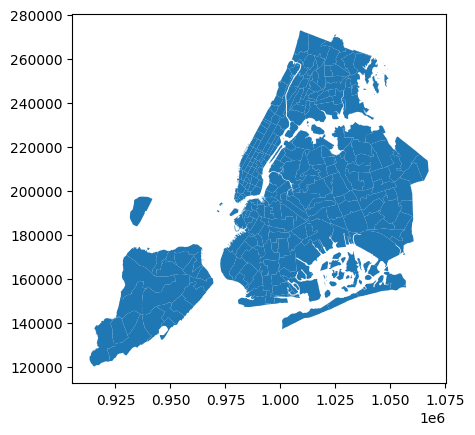

In [311]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [312]:
# Merge zones and trip records using locationID and PULocationID

ndf=pd.merge(ndf,zones,left_on='PULocationID',right_on='LocationID')

In [313]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1841619 entries, 0 to 1841618
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  airport_fee            float64       
 18  pickup_hour           

In [314]:
ndf.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,trip_duration,pickup_day,pickup_month,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:31:50,2023-01-01 00:44:17,2.0,2.85,1.0,263,41,1,15.60,...,747.0,1,1,263,0.037017,0.000066,Yorkville West,263,Manhattan,"POLYGON ((997493.323 220912.386, 997355.264 22..."
1,2,2023-01-01 00:10:50,2023-01-01 00:24:12,4.0,1.32,1.0,90,137,1,12.80,...,802.0,1,1,90,0.030759,0.000055,Flatiron,90,Manhattan,"POLYGON ((985265.129 208165.863, 985125.733 20..."
2,2,2023-01-01 00:25:37,2023-01-01 00:34:52,1.0,3.17,1.0,79,141,1,14.90,...,555.0,1,1,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
3,2,2023-01-01 00:27:26,2023-01-01 00:52:20,2.0,3.80,1.0,142,107,2,24.70,...,1494.0,1,1,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
4,2,2023-01-01 00:59:15,2023-01-01 01:23:15,1.0,7.97,99.0,140,17,0,36.83,...,1440.0,1,1,140,0.047584,0.000114,Lenox Hill East,140,Manhattan,"POLYGON ((995735.062 215619.835, 995670.105 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [315]:
# Group data by location and calculate the number of trips
total_trip_df=ndf.groupby('LocationID')['total_amount'].count()


In [316]:
total_trip_df.rename('trips',inplace=True)
total_trip_df

,trips
LocationID,
1,48
2,2
3,32
4,2196
5,9
...,...
259,39
260,312
261,9817


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [317]:
# Merge trip counts back to the zones GeoDataFrame
zones=pd.merge(zones,total_trip_df,on='LocationID')

In [318]:
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",48
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",32
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",2196
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",9
...,...,...,...,...,...,...,...,...
249,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",39
250,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",312
251,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",9817
252,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",24935


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

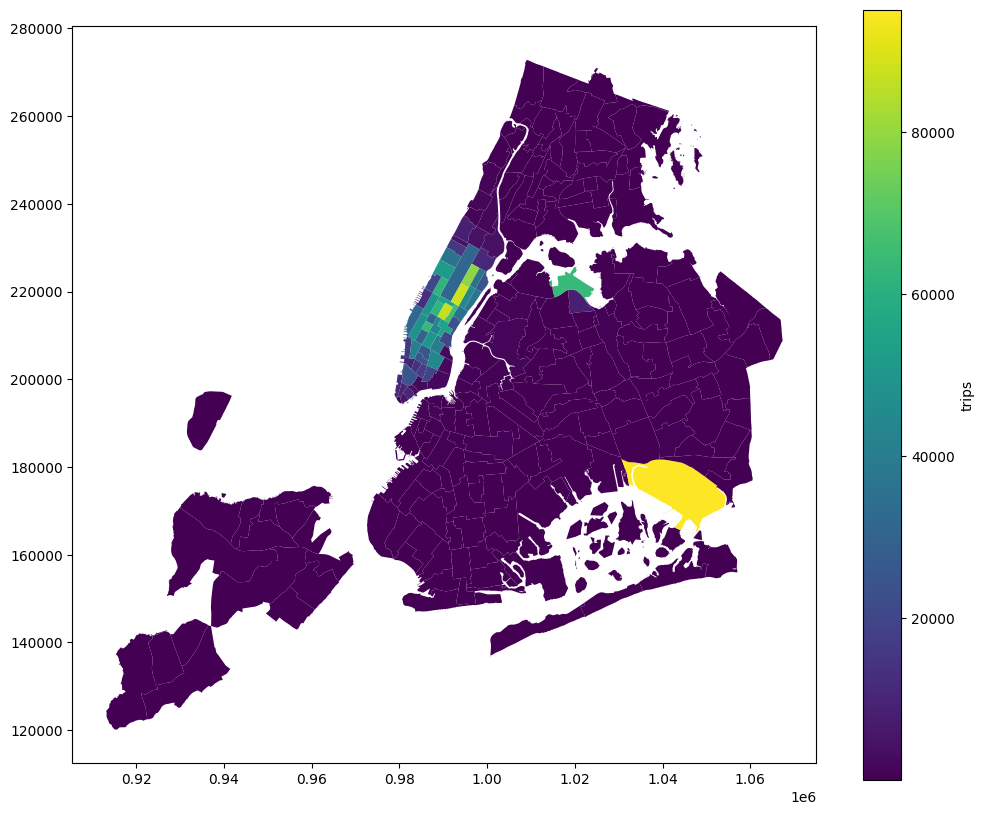

In [319]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones.plot(column='trips',ax = ax,legend = True,legend_kwds = {'label': "trips", 'orientation': "vertical"})
plt.show()


In [320]:
# can you try displaying the zones DF sorted by the number of trips?
zones.sort_values(by='trips',ascending=False)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trips
124,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",95063
227,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",87866
153,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",86628
226,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",78888
154,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",66136
...,...,...,...,...,...,...,...,...
148,156,0.144477,0.001052,Mariners Harbor,156,Staten Island,"MULTIPOLYGON (((934327.461 174416.463, 934330....",1
175,184,0.260816,0.001989,Pelham Bay Park,184,Bronx,"MULTIPOLYGON (((1037536.693 262105.37, 1037634...",1
178,187,0.126868,0.000421,Port Richmond,187,Staten Island,"MULTIPOLYGON (((946964.115 173161.64, 946977.8...",1
235,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",1


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones



From the general analysis done which includes different variable analysis, correlation between them and zones analysis, below are the findings.
1. `Derived variable analysis`: We derived couple of new variables from existing and that helped in getting the trend of the trips.
    * `Hour`: from the distribution ploted for the trips on every hour of the day, it is observed that the from afternoon to late evening is the prime time for the trips likely to happen. to be precise the numbers are high from 1PM in the afternoon to 9PM in the night.
    * `Day`: From the day of the week distribution it is observed that, there are less number of trips towards end of the month.
    * `Month`: MOnth distribution describes, how the trip 3rd quarter is comparatively generating less trips

2. `Revenue Analysis`: We have done the monthly and quarterly analysis. Monthly analysis suggests the revenue in the month of Februaly is least and May month has the highest pick ups. Simillarly the quarterly revenue analysis depicts that the 2nd and 4th quarter generating almost same revenue where 1st and 3rd revenue gen is minimal.

3. `Correlation Analysis` : We have done the dependancy check, mostly how fare is depndant on other variable of the data. from which we can conclude the fare is highly dependant on trip distance. i.e. when distance increases the fare will also increase. However, the other numerical attributes like Trip duration and passengers count does not have any huge affect on the fare amount.
Similarly tip amount and trip distance are dependant on each other. When distance increases the tip amount likely to be increased.

4. `Zone analysis`: By the help of zone data we got some meaningful insight about the trafic of the trips in different zones. fromt he plot we generated, JFK Airport zone is the busiest and Westerleigh i sthe lease busiest zone.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [321]:
# Calculate average trip duration for each route (PULocationID to DOLocationID) at each hour
average_trip_duration_by_route_hour = ndf.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['trip_duration'].mean()


In [322]:
# Calculate average trip distance for each route (PULocationID to DOLocationID) at each hour
average_trip_distance_by_route_hour = ndf.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['trip_distance'].mean()

# Calculate speed for each route at each hour (distance / duration)
speed_by_route_hour = average_trip_distance_by_route_hour / (average_trip_duration_by_route_hour / 3600) # Convert duration to hours for speed in miles/hour

# Identify and display the top 10 slowest routes (lowest speed)
display(speed_by_route_hour.nsmallest(10))

,,,0
PULocationID,DOLocationID,pickup_hour,
164,33,1,-807.631579
90,88,1,-60.644714
114,120,1,-49.195021
244,126,12,-18.504673
213,32,11,-13.514077
151,107,1,-8.327645
114,106,1,-4.899083
198,36,1,-1.939163
194,194,15,0.002741


How does identifying high-traffic, high-demand routes help us?

It helps in improving resource allocation by strategically positioning more cabs to fulfil the demand in busy zones.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [323]:
# Visualise the number of trips per hour and find the busiest hour

pickupcount=ndf.groupby('pickup_hour')['pickup_hour'].count()
pickupcount

,pickup_hour
pickup_hour,
0,51679
1,34672
2,22697
3,14910
4,9913
5,10546
6,25298
7,50102
8,69639


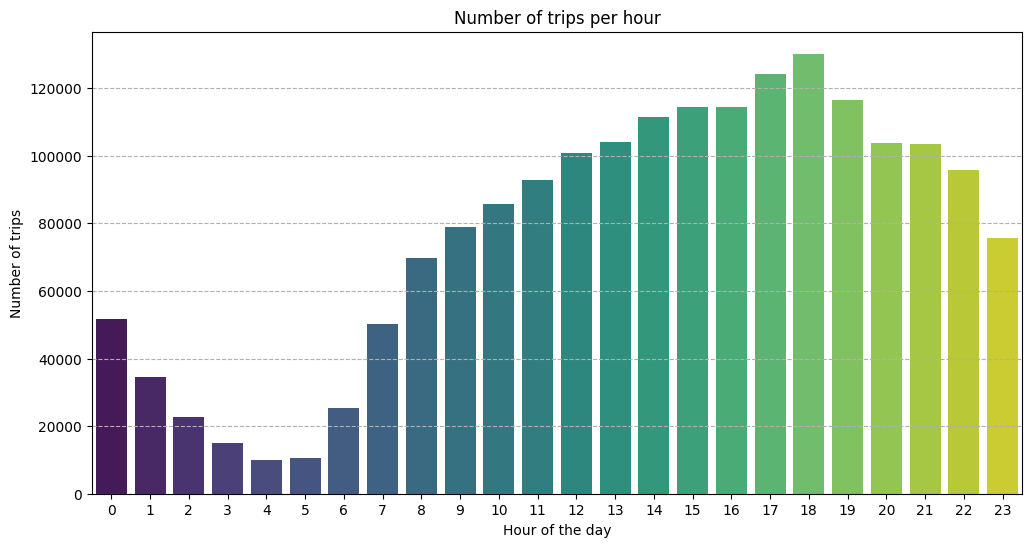

In [324]:
plt.figure(figsize=(12,6))
sns.barplot(x=pickupcount.index,y=pickupcount.values,palette='viridis')
plt.title('Number of trips per hour')
plt.xlabel('Hour of the day')
plt.ylabel('Number of trips')
plt.grid(axis='y',linestyle='--')
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [325]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

scaled_pickup_count = pickupcount / sample_fraction

print("Top 5 busiest hours with actual trip counts:")
display(scaled_pickup_count.nlargest(5))

Top 5 busiest hours with actual trip counts:


,pickup_hour
pickup_hour,
18,2603940.0
17,2484560.0
19,2331120.0
15,2286820.0
16,2286300.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [326]:
# Compare traffic trends for the week days and weekends
ndf['pickup_day_of_week'] = ndf['tpep_pickup_datetime'].dt.dayofweek


In [327]:
ndf.groupby('pickup_day_of_week')['pickup_day_of_week'].count()

,pickup_day_of_week
pickup_day_of_week,
0,229424
1,266740
2,282797
3,289130
4,273818
5,267859
6,231851


In [328]:
# Create a column to identify weekdays (0) and weekends (1)
ndf['is_weekend'] = ndf['pickup_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

<Figure size 1400x700 with 0 Axes>

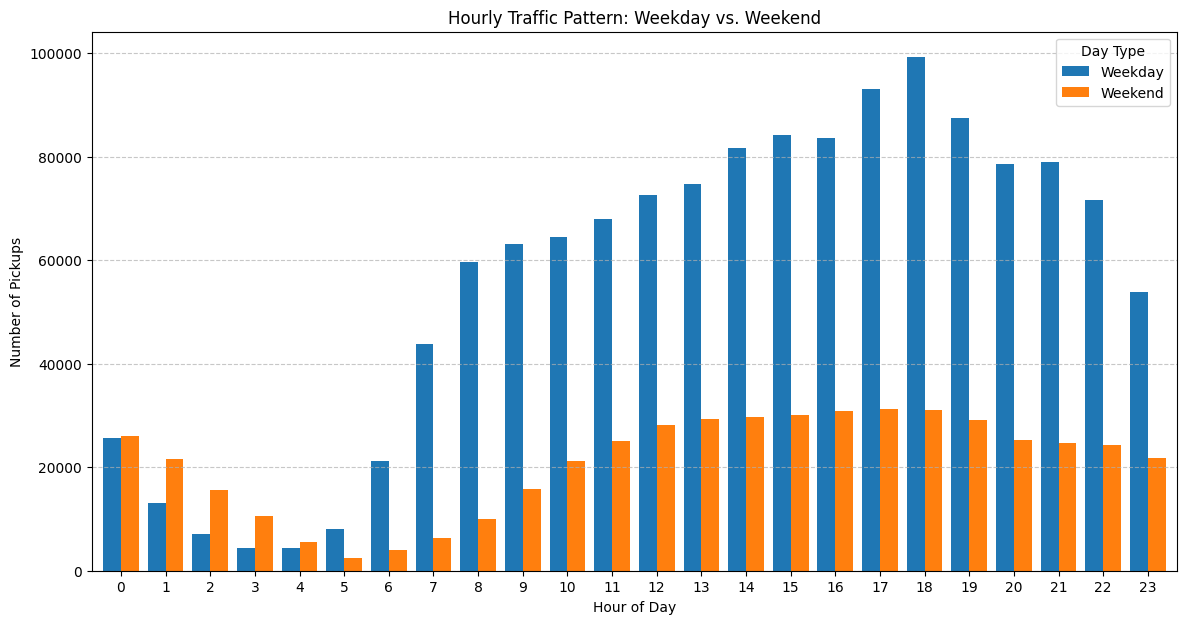

In [329]:
# Group by hour and weekend/weekday to get trip counts
hourly_traffic_pattern = ndf.groupby(['pickup_hour', 'is_weekend'])['tpep_pickup_datetime'].count().unstack()

plt.figure(figsize=(14, 7))
hourly_traffic_pattern.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Hourly Traffic Pattern: Weekday vs. Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=0)
plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

1. From the above distribution we can observe, mostly the weekdays are busier than weekends irrespective of the hour of the day. However, its opposite from midnight to 4AM morning, where the trips are more on weekends.  
2. for weekdays morning (7-9) and evening (5-7) rush
3. for weekends late night to early morning is the busiest hours.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [330]:
# Find top 10 pickup and dropoff zones

pickup_hourly_count_by_zone=ndf.groupby(['pickup_hour','PULocationID','zone']).size().reset_index(name='trip_count')
top_10_pickup_zones=pickup_hourly_count_by_zone.nlargest(10,'trip_count')
display(top_10_pickup_zones)


ndf['dropoff_hour'] = ndf['tpep_dropoff_datetime'].dt.hour
dropoff_hourly_count_by_zone=ndf.groupby(['dropoff_hour','DOLocationID','zone']).size().reset_index(name='trip_count')
top_10_dropoff_zones=dropoff_hourly_count_by_zone.nlargest(10,'trip_count')
display(top_10_dropoff_zones)

,pickup_hour,PULocationID,zone,trip_count
3682,18,161,Midtown Center,7519
3482,17,161,Midtown Center,7265
3270,16,161,Midtown Center,6695
3547,17,237,Upper East Side South,6652
3244,16,132,JFK Airport,6649
3739,18,237,Upper East Side South,6648
2905,14,237,Upper East Side South,6645
4378,22,132,JFK Airport,6616
3119,15,237,Upper East Side South,6615
3031,15,132,JFK Airport,6586


,dropoff_hour,DOLocationID,zone,trip_count
79650,15,236,Upper East Side South,1172
61329,12,237,Upper East Side North,1093
73504,14,236,Upper East Side South,1068
85867,16,236,Upper East Side South,1018
92097,17,236,Upper East Side South,1005
98577,18,237,Upper East Side North,988
79717,15,237,Upper East Side North,962
98513,18,236,Upper East Side South,941
67455,13,236,Upper East Side South,890
55224,11,237,Upper East Side North,872


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [331]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
ndf.drop('Shape_Area',axis=1,inplace=True)

In [332]:
trip_count_by_dropoff_zone = ndf.groupby(['DOLocationID'])['tpep_dropoff_datetime'].count().reset_index(name='drop_trip_count')
merged_zones=pd.merge(zones[['LocationID','zone','trips']],trip_count_by_dropoff_zone[['DOLocationID','drop_trip_count']],left_on='LocationID',right_on='DOLocationID')
display(merged_zones)

,LocationID,zone,trips,DOLocationID,drop_trip_count
0,1,Newark Airport,48,1,5524
1,2,Jamaica Bay,2,2,4
2,3,Allerton/Pelham Gardens,32,3,148
3,4,Alphabet City,2196,4,7038
4,5,Arden Heights,9,5,30
...,...,...,...,...,...
248,259,Woodlawn/Wakefield,39,259,197
249,260,Woodside,312,260,1334
250,261,World Trade Center,9817,261,8772
251,262,Yorkville East,24935,262,28735


In [333]:
merged_zones.drop(columns=['DOLocationID','LocationID'],axis=1,inplace=True)
merged_zones

,zone,trips,drop_trip_count
0,Newark Airport,48,5524
1,Jamaica Bay,2,4
2,Allerton/Pelham Gardens,32,148
3,Alphabet City,2196,7038
4,Arden Heights,9,30
...,...,...,...
248,Woodlawn/Wakefield,39,197
249,Woodside,312,1334
250,World Trade Center,9817,8772
251,Yorkville East,24935,28735


In [334]:
merged_zones['pickup_drop_ratio']=merged_zones['trips']/merged_zones['drop_trip_count']
merged_zones

,zone,trips,drop_trip_count,pickup_drop_ratio
0,Newark Airport,48,5524,0.008689
1,Jamaica Bay,2,4,0.500000
2,Allerton/Pelham Gardens,32,148,0.216216
3,Alphabet City,2196,7038,0.312020
4,Arden Heights,9,30,0.300000
...,...,...,...,...
248,Woodlawn/Wakefield,39,197,0.197970
249,Woodside,312,1334,0.233883
250,World Trade Center,9817,8772,1.119129
251,Yorkville East,24935,28735,0.867757


In [335]:
# Top 10 zones with highest pickup-dropoff ratio
top_10_ratio=merged_zones.nlargest(10,'pickup_drop_ratio')
display(top_10_ratio)

# buttom 10 zones with lowest pickup-dropoff ratio
buttom_10_ratio=merged_zones.nsmallest(10,'pickup_drop_ratio')
display(buttom_10_ratio)

,zone,trips,drop_trip_count,pickup_drop_ratio
68,East Elmhurst,8255,878,9.402050
124,JFK Airport,95063,20999,4.527025
130,LaGuardia Airport,64025,24014,2.666153
177,Penn Station/Madison Sq West,63604,40585,1.567180
106,Greenwich Village South,24700,17905,1.379503
41,Central Park,31061,22613,1.373590
238,West Village,41213,30927,1.332590
154,Midtown East,66136,52921,1.249712
153,Midtown Center,86628,72603,1.193174
97,Garment District,30381,25481,1.192300


,zone,trips,drop_trip_count,pickup_drop_ratio
0,Newark Airport,48,5524,0.008689
26,Breezy Point/Fort Tilden/Riis Beach,1,38,0.026316
234,West Brighton,1,32,0.031250
240,Westerleigh,1,30,0.033333
148,Mariners Harbor,1,26,0.038462
107,Grymes Hill/Clifton,1,24,0.041667
246,Windsor Terrace,34,768,0.044271
110,Heartland Village/Todt Hill,2,42,0.047619
175,Pelham Bay Park,1,21,0.047619
94,Forest Park/Highland Park,3,59,0.050847


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [336]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
top_10_pickup_zone_at_night=pickup_hourly_count_by_zone[(pickup_hourly_count_by_zone.pickup_hour>=23) | (pickup_hourly_count_by_zone.pickup_hour<=5)].nlargest(10,'trip_count')
display(top_10_pickup_zone_at_night)

top_10_dropoff_zones_at_night=dropoff_hourly_count_by_zone[(dropoff_hourly_count_by_zone.dropoff_hour>=23) | (dropoff_hourly_count_by_zone.dropoff_hour<=5)].nlargest(10,'trip_count')
display(top_10_dropoff_zones_at_night)


,pickup_hour,PULocationID,zone,trip_count
4548,23,132,JFK Airport,6095
4552,23,138,LaGuardia Airport,3876
74,0,132,JFK Airport,3868
4516,23,79,East Village,3683
46,0,79,East Village,3659
4631,23,249,West Village,3581
203,1,79,East Village,3385
4617,23,230,Times Sq/Theatre District,3157
151,0,249,West Village,3144
4495,23,48,Clinton East,3085


,dropoff_hour,DOLocationID,zone,trip_count
131490,23,265,JFK Airport,257
6142,0,265,JFK Airport,230
126385,23,68,Clinton East,230
1668,0,79,West Village,227
7564,1,79,West Village,208
130712,23,239,Lincoln Square East,206
126703,23,79,West Village,200
8058,1,107,East Village,192
130643,23,238,Lincoln Square East,192
1619,0,79,East Village,191


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [337]:
# Filter for night hours (11 PM to 5 AM)

revenue_at_night=ndf.groupby('pickup_hour')['total_amount'].sum().reset_index(name='revenue')

display(revenue_at_night[(revenue_at_night.pickup_hour>=23) | (revenue_at_night.pickup_hour<=5)])

,pickup_hour,revenue
0,0,1507051.45
1,1,924615.65
2,2,573374.74
3,3,396358.14
4,4,336097.29
5,5,409927.23
23,23,2311263.49


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [338]:
# Analyse the fare per mile per passenger for different passenger counts
ndf['fare_per_mile']=ndf.trip_distance/(ndf.fare_amount/ndf.passenger_count)

display(ndf['fare_per_mile'])

,fare_per_mile
0,0.365385
1,0.412500
2,0.212752
3,0.307692
4,0.216400
...,...
1841614,0.291549
1841615,0.884956
1841616,0.317571
1841617,0.148437


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [339]:
# Compare the average fare per mile for different days and for different times of the day

average_fare_hour=ndf.groupby(['pickup_hour'])['fare_per_mile'].mean().reset_index(name='average_fare_per_mile')
display(average_fare_hour)

average_fare_day=ndf.groupby(['pickup_day_of_week'])['fare_per_mile'].mean().reset_index(name='average_fare_per_mile')
display(average_fare_day)

,pickup_hour,average_fare_per_mile
0,0,0.278432
1,1,0.239200
2,2,0.298140
3,3,0.253738
4,4,0.287040
5,5,0.278474
6,6,0.238929
7,7,0.227791
8,8,0.206550
9,9,0.193327


,pickup_day_of_week,average_fare_per_mile
0,0,0.215157
1,1,0.200589
2,2,0.199587
3,3,0.206769
4,4,0.205480
5,5,0.222948
6,6,0.255011


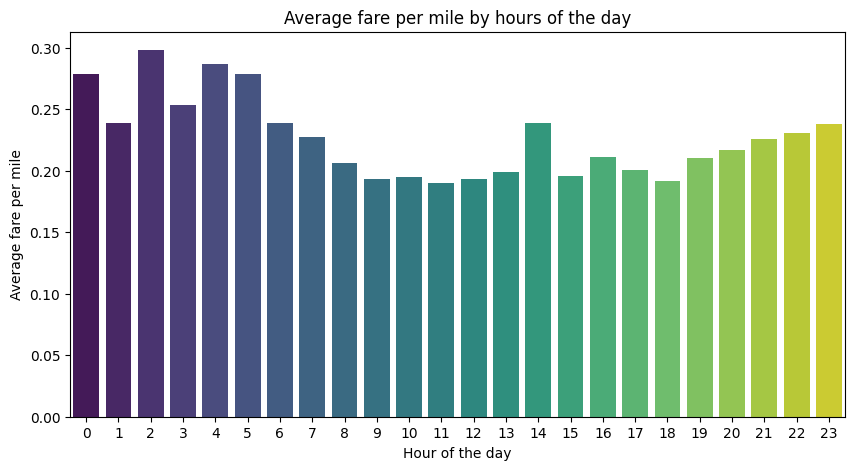

In [340]:
plt.figure(figsize=(10,5))
sns.barplot(data=average_fare_hour,x=average_fare_hour.pickup_hour,y=average_fare_hour.average_fare_per_mile,palette='viridis')
plt.title('Average fare per mile by hours of the day')
plt.xlabel('Hour of the day')
plt.ylabel('Average fare per mile')
plt.show()


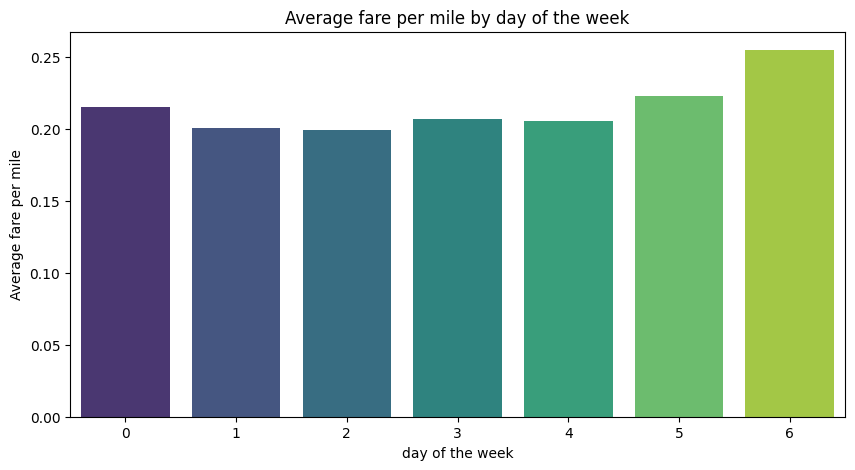

In [341]:
plt.figure(figsize=(10,5))
sns.barplot(data=average_fare_day,x=average_fare_day.pickup_day_of_week,y=average_fare_day.average_fare_per_mile,palette='viridis')
plt.title('Average fare per mile by day of the week')
plt.xlabel('day of the week')
plt.ylabel('Average fare per mile')
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [342]:
# Compare fare per mile for different vendors
average_fare_per_mile_by_vendor=ndf.groupby(['VendorID','pickup_hour'])['fare_per_mile'].mean().reset_index(name='average_fare_per_mile')
display(average_fare_per_mile_by_vendor)

,VendorID,pickup_hour,average_fare_per_mile
0,1,0,0.399928
1,1,1,0.228331
2,1,2,0.451136
3,1,3,0.233157
4,1,4,0.356533
5,1,5,0.325865
6,1,6,0.239589
7,1,7,0.260448
8,1,8,0.223426
9,1,9,0.181422


In [343]:
vendor_map = {
    1: 'Creative Mobile Technologies, LLC',
    2: 'Curb Mobility, LLC',
    3: 'Myle Technologies Inc',
    4: 'Helix'
}

average_fare_per_mile_by_vendor['vendor_name'] = average_fare_per_mile_by_vendor['VendorID'].map(vendor_map)

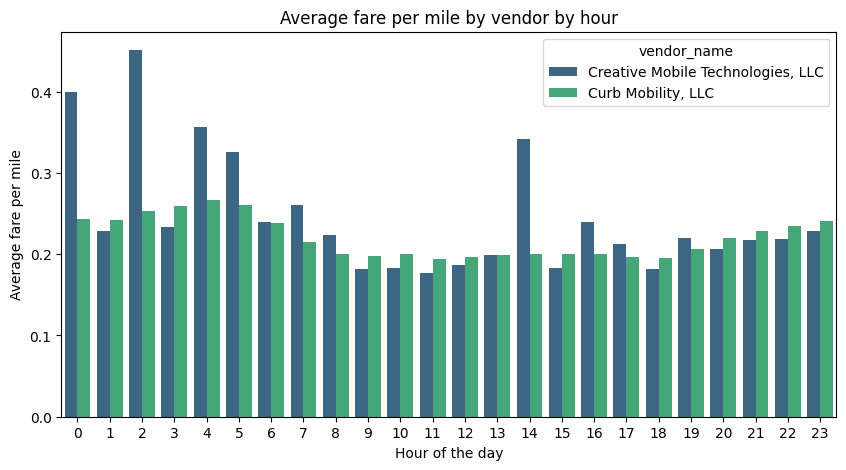

In [344]:
plt.figure(figsize=(10,5))
sns.barplot(data=average_fare_per_mile_by_vendor,
            x='pickup_hour',
            y='average_fare_per_mile',
            palette='viridis',
            hue='vendor_name')
plt.title('Average fare per mile by vendor by hour')
plt.xlabel('Hour of the day')
plt.ylabel('Average fare per mile')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [345]:
# Defining distance tiers
ndf['distance_tier'] = pd.cut(
    ndf['trip_distance'],
    bins=[0, 2, 5, np.inf],
    labels=['0-2 miles', '2-5 miles', '>5 miles']
)


In [346]:
ndf['fare_per_mile'] = ndf['fare_amount'] / ndf['trip_distance']

In [347]:
tier_analysis = (
    ndf.groupby(['VendorID', 'distance_tier'])['fare_per_mile']
       .mean()
       .reset_index()
)

display(tier_analysis)

,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,9.899001
1,1,2-5 miles,6.381702
2,1,>5 miles,4.425376
3,2,0-2 miles,17.736599
4,2,2-5 miles,6.536753
5,2,>5 miles,4.491462


In [348]:
vendor_map = {
    1: 'Creative Mobile Technologies, LLC',
    2: 'Curb Mobility, LLC',
    3: 'Myle Technologies Inc',
    4: 'Helix'
}

tier_analysis['vendor_name']=tier_analysis['VendorID'].map(vendor_map)

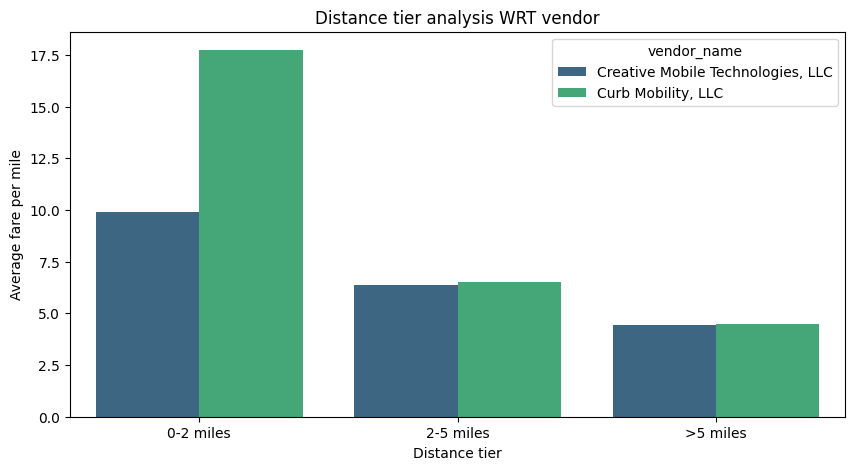

In [349]:
plt.figure(figsize=(10,5))
sns.barplot(data=tier_analysis,
            x='distance_tier',
            y='fare_per_mile',
            palette='viridis',
            hue='vendor_name')
plt.title('Distance tier analysis WRT vendor')
plt.xlabel('Distance tier')
plt.ylabel('Average fare per mile')
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [350]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

ndf['tip_percentage'] = (ndf['tip_amount'] / ndf['total_amount']) * 100

display(ndf['tip_percentage'])

,tip_percentage
0,16.666667
1,16.666667
2,16.666667
3,0.000000
4,16.673469
...,...
1841614,23.076923
1841615,6.756757
1841616,10.788650
1841617,11.000000


In [351]:
ndf.groupby('distance_tier')['tip_percentage'].mean()

,tip_percentage
distance_tier,
0-2 miles,12.130866
2-5 miles,12.224482
>5 miles,11.295834


In [352]:
ndf.groupby('passenger_count')['tip_percentage'].mean()

,tip_percentage
passenger_count,
1.0,12.118458
2.0,11.790058
3.0,11.368630
4.0,10.493301
5.0,12.147741
6.0,12.228974


In [353]:
ndf.groupby('pickup_hour')['tip_percentage'].mean()

,tip_percentage
pickup_hour,
0,11.916052
1,11.879759
2,11.704590
3,11.226568
4,10.474644
5,10.326180
6,11.100960
7,11.916430
8,12.235853


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [354]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [355]:
print(ndf['pickup_hour'].isnull().sum())
print(ndf.tail())

0
         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
1841614         2  2023-12-29 21:28:58   2023-12-29 21:41:44              2.0   
1841615         2  2023-12-29 21:02:48   2023-12-29 21:22:31              5.0   
1841616         2  2023-12-29 21:09:47   2023-12-29 21:55:37              1.0   
1841617         1  2023-12-29 21:38:48   2023-12-29 21:51:04              1.0   
1841618         2  2023-12-29 21:04:31   2023-12-29 21:44:05              1.0   

         trip_distance  RatecodeID  PULocationID  DOLocationID  payment_type  \
1841614           2.07         1.0           143           151             1   
1841615           4.00         1.0           261            68             1   
1841616          22.23         2.0           132            87             1   
1841617           1.90         1.0           233           263             1   
1841618          16.37         1.0           132            37             1   

         fare_amount  ...     

In [356]:
day_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

ndf['pickup_day_name'] = ndf['pickup_day_of_week'].map(day_map)

In [357]:
# See how passenger count varies across hours and days

passenger_count_by_hour_day=ndf.groupby(['pickup_hour','pickup_day_name'])['passenger_count'].mean().reset_index(name='average_passenger_count')
display(passenger_count_by_hour_day)


,pickup_hour,pickup_day_name,average_passenger_count
0,0,Friday,1.381879
1,0,Monday,1.382276
2,0,Saturday,1.452639
3,0,Sunday,1.472985
4,0,Thursday,1.343657
...,...,...,...
163,23,Saturday,1.494428
164,23,Sunday,1.408934
165,23,Thursday,1.376325
166,23,Tuesday,1.348350


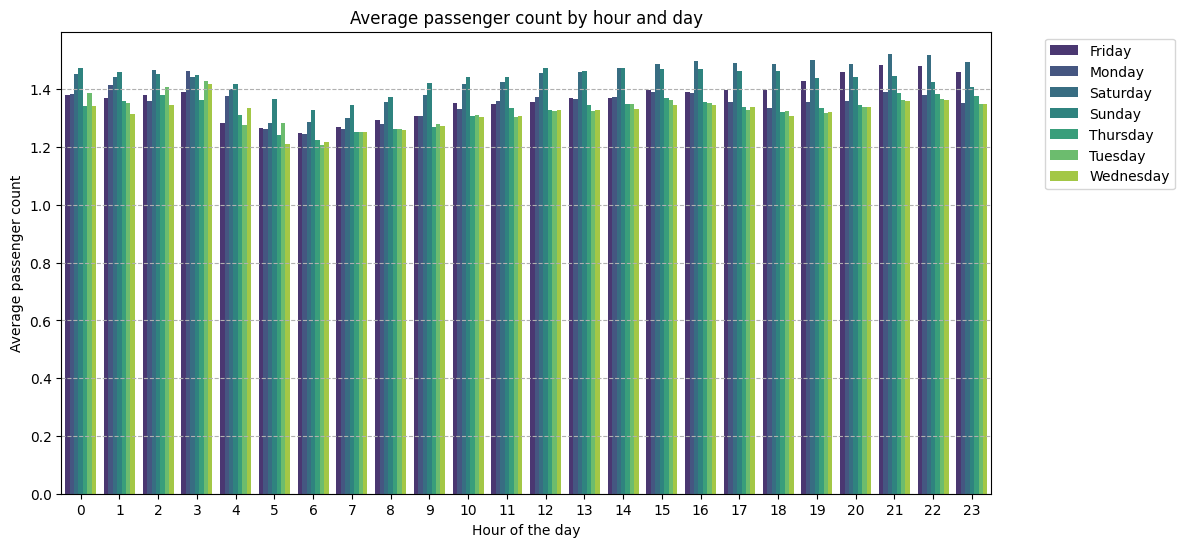

In [358]:
plt.figure(figsize=(12,6))
sns.barplot(data=passenger_count_by_hour_day,
            x='pickup_hour',
            y='average_passenger_count',
            palette='viridis',
            hue='pickup_day_name')
plt.title('Average passenger count by hour and day')
plt.xlabel('Hour of the day')
plt.ylabel('Average passenger count')
plt.grid(axis='y',linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [359]:
# How does passenger count vary across zones
passenger_count_across_zone=ndf.groupby(['zone'])['passenger_count'].mean().reset_index(name='average_passenger_count')
display(passenger_count_across_zone.nlargest(10,'average_passenger_count'))

,zone,average_passenger_count
3,Arrochar/Fort Wadsworth,1.954545
9,Battery Park,1.729567
185,Red Hook,1.728972
197,Saint Michaels Cemetery/Woodside,1.727273
53,Country Club,1.666667
88,Flushing Meadows-Corona Park,1.531969
250,World Trade Center,1.528573
41,Chinatown,1.500770
54,Crotona Park,1.500000
100,Green-Wood Cemetery,1.500000


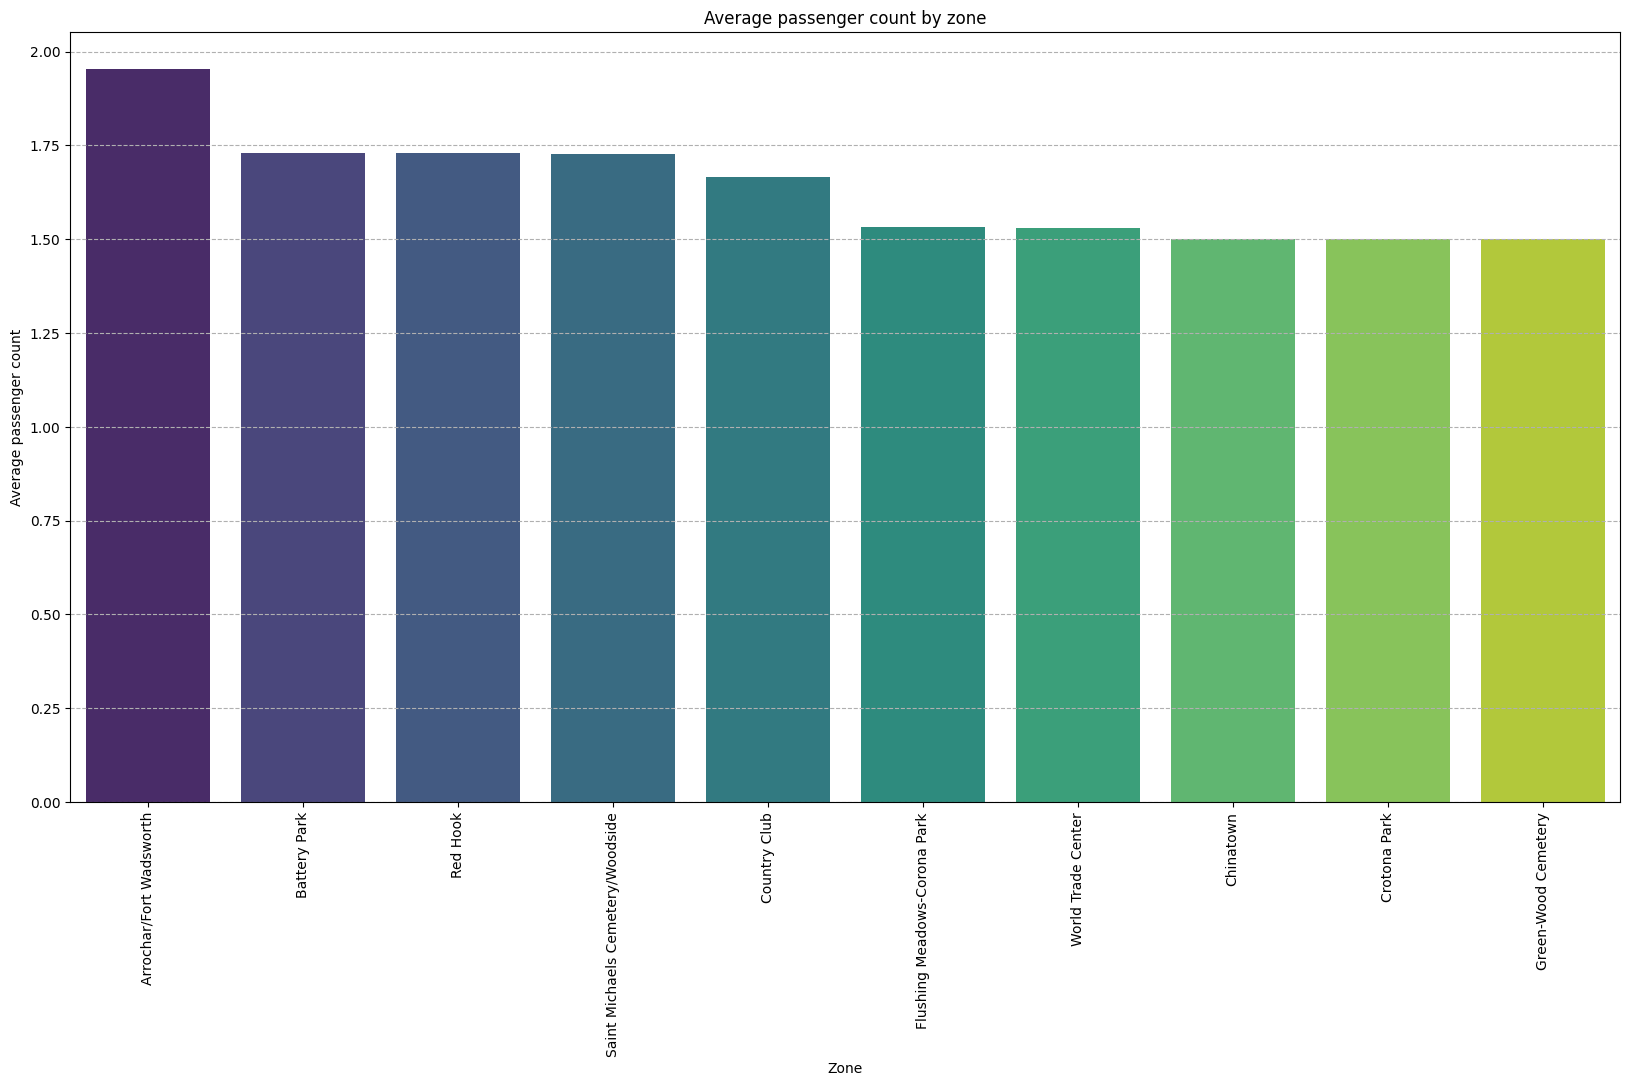

In [360]:
plt.figure(figsize=(20,10))
sns.barplot(data=passenger_count_across_zone.nlargest(10,'average_passenger_count'),
            x='zone',
            y='average_passenger_count',
            palette='viridis')
plt.title('Average passenger count by zone')
plt.xlabel('Zone')
plt.ylabel('Average passenger count')
plt.xticks(rotation=90)
plt.grid(axis='y',linestyle='--')
plt.show()

In [361]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [362]:
# How often is each surcharge applied?

pickup_extra_charge=ndf.groupby(['PULocationID','zone','pickup_hour'])['extra'].mean().reset_index(name='pickup_extra_amount')
display(pickup_extra_charge.nlargest(10,'pickup_extra_amount'))
dropoff_extra_charge=ndf.groupby(['DOLocationID','zone','dropoff_hour'])['extra'].mean().reset_index(name='drop_extra_amount')
display(dropoff_extra_charge.nlargest(10,'drop_extra_amount'))


,PULocationID,zone,pickup_hour,pickup_extra_amount
4427,253,Willets Point,16,7.500000
2339,138,LaGuardia Airport,19,7.329124
2337,138,LaGuardia Airport,17,7.317537
2338,138,LaGuardia Airport,18,7.290958
2336,138,LaGuardia Airport,16,7.219467
2340,138,LaGuardia Airport,20,6.559022
2341,138,LaGuardia Airport,21,6.541756
2342,138,LaGuardia Airport,22,6.524576
2343,138,LaGuardia Airport,23,6.491228
2320,138,LaGuardia Airport,0,6.476558


,DOLocationID,zone,dropoff_hour,drop_extra_amount
66431,144,East Elmhurst,18,11.75
126284,261,LaGuardia Airport,6,11.75
106933,232,East Elmhurst,18,10.50
119252,246,East Elmhurst,19,10.50
158,1,East Elmhurst,2,10.25
17468,45,East Elmhurst,21,10.25
21037,50,East Elmhurst,20,10.25
60885,140,East Elmhurst,3,10.25
94477,209,LaGuardia Airport,1,10.25
95417,211,East Elmhurst,22,10.25


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

### **4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies



Routing and Dispatching Optimization:

1.  Dynamic Dispatching based on Hourly Trends:
    * Peak Hours: The analysis shows that 1 PM to 9 PM are the busiest hours, with 5 PM to 7 PM being the absolute peak. During these times, more taxis should be dynamically dispatched to high-demand areas to minimize wait times and maximize pickup efficiency.
    * Off-Peak Hours (Early Morning 1 AM - 5 AM): Weekends show higher activity in these hours compared to weekdays. Dispatching should be adjusted accordingly, with fewer taxis on weekdays and more strategically placed taxis on weekends during these times.

2.  Addressing Slow Routes:
    * The identification of slow routes (low speed from distance/duration) indicates potential bottlenecks. For these routes, consider:
        * Alternative Routes: Provide drivers with alternative, faster routes, possibly using real-time traffic data integration.
        * Driver Training/Guidance: Educate drivers on efficient navigation during specific hours or for particular zone-to-zone trips that consistently show low speeds.
        * Incentivize Faster Routes: Offer small incentives for drivers who maintain better speeds on traditionally slow routes (without compromising safety).

3.  Predictive Dispatching:
    * Leverage historical data (like the monthly trends showing February/March and August/September as lower activity months, and May/October as higher) to anticipate demand fluctuations. Pre-emptively position more drivers during high-demand months and consider promotional activities during slower months to balance supply and demand.

4.  Vendor-Specific Efficiency:
    * If specific vendors consistently show lower efficiency (e.g., higher average trip duration for similar distances, or lower speeds on common routes), investigate their operational practices and provide support or set performance targets.

By implementing these strategies, the taxi operation can significantly reduce idle time for drivers, improve service speed for passengers, and ultimately increase the number of completed trips.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

strategic Cab Positioning:

1.  Concentrate on High Pickup Zones:
    * JFK Airport, Upper East Side South/North, Midtown Center: These zones consistently show the highest number of pickups across different hours. Taxis should be concentrated here, especially during peak hours (afternoon to late evening).
    * Night-time Hotspots: During night hours (11 PM to 5 AM), specific zones like JFK Airport, LaGuardia Airport, East Village, and Lincoln Square East become primary pickup locations. Shifting available taxis to these areas during these hours will capture demand effectively.

2.  Address Pickup/Dropoff Imbalances:
    * High Pickup/Dropoff Ratio (e.g., East Elmhurst, JFK Airport, LaGuardia Airport): These zones are primarily pickup generators. Cabs should be consistently available here, even if it means deadheading from nearby lower-demand zones after a drop-off. Consider incentivizing drivers to travel to these zones for pickups.
    * Low Pickup/Dropoff Ratio (e.g., Newark Airport, Jamaica Bay, West Brighton): These zones are predominantly drop-off points. Drivers dropping off here might need incentives to move to higher-demand pickup zones or to wait if a return trip is highly probable.

3.  Weekday vs. Weekend Positioning:
    * Weekdays: Focus positioning efforts in business districts and high-traffic commercial areas during morning and evening rush hours (7-9 AM, 5-7 PM). Manhattan zones will likely be central.
    * Weekends: Shift focus to entertainment hubs, airports, and residential areas, especially during late-night and early morning hours where weekend traffic surpasses weekdays.

4.  Utilize Monthly Trends:
    * Adjust overall fleet deployment based on monthly demand. During high-demand months (May, October), a larger active fleet might be required. During lower-demand months (February, March, August, September), operations can be scaled down or promotional strategies can be implemented to stimulate demand.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.



Data-Driven Pricing Strategy:

1. Dynamic Pricing based on Demand and Time:
    * Peak Hour Surcharges: Implement surge pricing during the busiest hours (1 PM - 9 PM, especially 5 PM - 7 PM), and particularly during weekend late nights (1 AM - 4 AM) when demand is high. This will maximize revenue capture during periods of high demand.
    * Off-Peak Incentives: Offer discounts or loyalty bonuses during off-peak hours (e.g., early weekday mornings, mid-day lull) to stimulate demand and ensure steady utilization of the fleet.

2.  Tiered Pricing based on Distance:
    * The analysis of average fare per mile by distance tiers shows variations among vendors. The `fare_per_mile` tends to be higher for shorter trips (0-2 miles) and decreases for longer trips (>5 miles). This indicates that initial costs are higher, and longer trips offer more value per mile.
    * Short Trips (0-2 miles): Maintain a competitive base fare. If the current `fare_per_mile` for very short distances is too high, it might deter customers. If it's too low, it might not cover operational costs.
    * Medium Trips (2-5 miles): This segment generally offers a balanced `fare_per_mile`. Focus on efficiency to make these trips more profitable.
    * Longer Trips (>5 miles): Consider offering slight per-mile discounts or fixed-fare options for longer distances to attract customers for these more profitable trips.

3.  Vendor-Specific Adjustments for Competitiveness:
    * Continuously monitor competitor pricing. If `VendorID 2 (Curb Mobility, LLC)` consistently has a higher `fare_per_mile` across various distance tiers, they might be perceived as premium or might lose customers to more affordable options. Adjust pricing to remain competitive while reflecting service quality.
    * `VendorID 1 (Creative Mobile Technologies, LLC)` generally shows lower `fare_per_mile`. This might be a strategy to capture market share, or it could indicate an opportunity to slightly increase rates without losing competitiveness.

4.  Tip-Driven Incentives for Drivers:
    * Since tip amounts are positively correlated with `trip_distance`, drivers completing longer trips are likely to earn more in tips. Consider highlighting this to drivers to encourage accepting longer trips.
    * Analyze factors leading to low tip percentages (e.g., specific times, zones, or perceived service quality issues) and implement driver training or passenger feedback mechanisms to improve service and potentially increase tips.

5.  Surcharge Optimization:
    * Review the application of `extra` charges and `congestion_surcharge`. If certain zones or hours trigger these more frequently, ensure transparency with customers. These charges contribute to the total amount and affect perceived fare. Optimizing their application can balance revenue and customer satisfaction.